In [4]:
import os
os.environ["OMP_NUM_THREADS"] = "6"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

from collections import Counter
from scipy.stats import chi2_contingency

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


#für Hierarchisches Clustering
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

In [16]:
#angepasst auf finale datei
seq_regions = ['SEQ_H1', 'SEQ_H2', 'SEQ_L1', 'SEQ_L2', 'SEQ_L3']
cf_regions = ['CF_H1', 'CF_H2', 'CF_L1', 'CF_L2', 'CF_L3']
df = (
    pd.read_csv("data/ab_ag_scalop.tsv", sep="\t")
    .dropna(subset=seq_regions)
    .dropna(subset=cf_regions)
    .drop_duplicates(subset=seq_regions) 
)
antigen_labels = df["antigen_name"].tolist()

In [12]:
def residue_percentage(sequence):
    """
    Berechnet den prozentualen Anteil jeder Aminosäure in der gegebenen Sequenz und gibt eine Liste seq_residues zurück,
    die jede Aminosäure als Tupel (residue, percentage) enthält.
    sequence: list, die eine CDR-Sequenz repäsentiert, und deren Einträge aus einem String pro Aminosäure besteht, z.B. ['A', 'R', 'N', ...]
    """
    residues = ["A", "C", "D", "E", "F", "G", "H", "I", "K", "L", "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y"]
    seq_residues = []
    for residue in residues:
        percentage = sequence.count(residue) / len(sequence)
        seq_residues.append((residue, percentage))
    return seq_residues


def show_feature_space(feature_space, CDR_region, antigen_labels):#zusätzliches Argument für color-coding: antigen
    """
    Visualisiert den Feature-Space der CDR-Sequenzen mittels PCA in 3D.
    feature_space: pd.DataFrame, der die PDB-IDs in einer Spalte "pdb" und die prozentualen Anteile der Aminosäuren in den entsprechenden CDR-Sequenzen
    in je einer Spalte pro Aminosäure enthält.
    """
    X = feature_space.drop(columns=["pdb"])
    coords = PCA(n_components=2).fit_transform(X)
    
    #### Farbzuordnung vorbereiten
    unique_antigens = sorted(list(set(antigen_labels)))
    color_map = plt.get_cmap('gist_rainbow_r', len(unique_antigens))
    color_dict = {antigen: color_map(i) for i, antigen in enumerate(unique_antigens)}
    colors = [color_dict[a] for a in antigen_labels]
   

    # Plotten der PCA-Koordinaten in 2D
    fig, (ax_scatter, ax_legend) = plt.subplots(2, 1, figsize=(10,10), gridspec_kw={'height_ratios': [4,1]})
    ax_scatter.scatter(coords[:, 0], coords[:, 1], c=colors, s=20, alpha=0.7)#zusätzliche Argumente für color-coding: c=color_codes, cmap='tab20', 
    ax_scatter.set_xlabel("PCA 1")
    ax_scatter.set_ylabel("PCA 2")
    ax_scatter.set_title(f"PCA of {CDR_region} Sequences")


    # 2. Legende als eigene Figure
    legend_fig, legend_ax = plt.subplots(figsize=(12, 12))  # Größe anpassen je nach Anzahl Antigene
    legend_ax.axis('off')  # Keine Achsen

    # Erstelle Handles
    handles = [mlines.Line2D([], [], color=color_dict[ant], marker='o', linestyle='None',
                             markersize=8, label=ant)
               for ant in unique_antigens]

    # Erzeuge Legende
    legend = legend_ax.legend(handles=handles, loc='center', ncol=1, fontsize='small')  # ncol=1 → alle untereinander

    legend_fig.tight_layout()
    plt.show()

In [13]:
feature_spaces = {}
for region in regions: 
    fs_rows = []
    for df_row in df.itertuples():
        # Metadaten der PDB-Einträge
        pdb = df_row.pdb
        antigen_name = df_row.antigen_name
        antigen_species = df_row.antigen_species

        # AS-Häufigkeiten-Koordinaten der PDB-Einträge
        seq_as_str = getattr(df_row, region)
        seq_as_list = list(seq_as_str)
        residues_percentages = residue_percentage(seq_as_list)
        percentages = [pair[1] for pair in residues_percentages]

        # Längen-Koordinate der PDB-Einträge    
        seq_length = getattr(df_row, f"{region}_length")

        # Erstellen und Anhängen der Zeile eines PDB-Eintrages für den Feature-Space
        fs_row = [pdb] + [antigen_name] + [antigen_species] + [seq_length] + percentages
        fs_rows.append(fs_row)

    # Umwandeln des Feature-Space von einer Liste in einen DataFrame
    feature_space = pd.DataFrame(fs_rows, columns=["pdb"] + ["antigen_name"] + ["antigen_species"] + ["seq_length"] + residues)
    
    # Z-Transformation der Sequenzlängen und der AS-Häufigkeiten
    columns_to_scale = ["seq_length"] + residues
    feature_space_z = feature_space.copy()
    feature_space_z[columns_to_scale] = scaler.fit_transform(feature_space[columns_to_scale])
    feature_spaces[region] = feature_space_z


AttributeError: 'Pandas' object has no attribute 'SEQ_H1_length'

In [9]:

for region in regions: 
    feature_space_visualize = feature_spaces[region].drop(columns=["antigen_name", "antigen_species"])
    show_feature_space(feature_space_visualize, region, antigen_labels)


#Überprüfung ob alle punkte mit gleichem antigen-name die gleiche farbe haben am bsp influenza a virus
idx_influenzaavirus = [i for i, a in enumerate(antigen_labels) if a == "influenza a virus"]
set([colors[i] for i in idx_influenzaavirus])

#alle farben pro antigen tabellarisch
for ant in set(antigen_labels):
    print(f"{ant}: {color_dict[ant]}")

KeyError: 'SEQ_H1'

In [ ]:
#elbow method 
#der erste teil ist wieder nur wdh weil der sonst die variabeln nicht findet

for region in regions:
    feature_space_elbow = feature_spaces[region].drop(columns=["antigen_name", "antigen_species"])

    #berücksichtigt nur top 10 aufgrund wie feature space definiert wurde
    X = feature_space_elbow.drop(columns=["pdb"])
    coords = PCA(n_components=2).fit_transform(X)

    #elbow method
    #inertia => Summe der quadrierten Abstände der Punkte zum jeweiligen Cluster-Zentrum => je kleiner, desto besser

    # Range of cluster numbers to try
    cluster_range = range(1, 11)  # Teste 1-10 Cluster

    # Hier Inertia-Werte speichern, [] für liste
    inertia_values = []

    # Berechne KMeans für jede Cluster-Anzahl
    for n_clusters in cluster_range:
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        kmeans.fit(coords)  # fit passt daten an modell an => kmeans bekommt daten (coords der antikörper punkte) und initialisiert Cluster Zentren und macht dann iterative optimierung 
        # also weist punkte dem nächsten cluster zentrum zu, bei den gebildeten cluster wenn neue zentren berechnet und die punkte werden neu zugeordnet
        inertia_values.append(kmeans.inertia_)

    # Plot der Elbow-Kurve
    plt.figure(figsize=(8, 5))
    plt.plot(cluster_range, inertia_values, marker='o')
    plt.xlabel('Anzahl der Cluster (n_clusters)')
    plt.ylabel('Inertia (Summe der quadrierten Abstände)')
    plt.title(f'Elbow-Methode zur Bestimmung optimaler Clusterzahl ({region})')
    plt.xticks(cluster_range) #x achse werden dann anzhal cluster gezeigt
    plt.grid(True) #gitternetzlinien im plot
    plt.tight_layout()
    plt.show()


In [ ]:
# Clustering auf basis der PCA
#kmeans mit 3 => laut elbow method am sinnvollsten

 # Schleife über die CDR-Regionen, um den Feature-Space für jede CDR-Sequenz zu erstellen:
for region in regions:
    feature_space_kmeans = feature_spaces[region].drop(columns=["antigen_name", "antigen_species"])
    
    #berücksichtigt nur top 10 aufgrund wie feature space definiert wurde
    X = feature_space_kmeans.drop(columns=["pdb"])
    coords = PCA(n_components=2).fit_transform(X)

    # n_clusters frei wählbar
    kmeans = KMeans(n_clusters=3, random_state=42) #random state wichtig damit auch bei jeden durchlauf gleiche cluster entstehen
    cluster_labels = kmeans.fit_predict(coords) #fit predict führt clustering im 2d pca space durch

    # Plot => Cluster einfärben
    plt.figure(figsize=(10, 8))
    plt.scatter(coords[:, 0], coords[:, 1], c=cluster_labels, cmap='tab10', s=20, alpha=0.7) #c=cöuster labels färbt die punkte nach cluster; tab10 => 10 farben, alpha => tranparenz damit überlappungen sichtbar, s => punktgröße
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"PCA + KMeans Clustering ({region})")
    plt.colorbar(label='Cluster Label')
    plt.tight_layout()
    plt.show()

    #antigen names häufigkeiten in den clustern

    # Erzeuge Mapping: cluster_label → liste von antigen names
    # Dictionary ({} => speichert key => value paare) bauen, in dem für jedes Cluster die Liste der zugehörigen Antigen-Namen gespeichert wird
    cluster_antigen_mapping = {}

    # Gehe alle Punkte durch (alle Antikörper im PCA/Feature-Space)
    # → zip(cluster_labels, antigen_labels) gibt für jeden Punkt: cluster_label: die Cluster-Nummer (z.B. 0, 1, 2, ...) & antigen_name: der Antigen-Name dieses Antikörpers
    for cluster_label, antigen_name in zip(cluster_labels, antigen_labels):

        # Wenn dieses Cluster-Label noch nicht im Dictionary ist => leeres Array initialisieren
        if cluster_label not in cluster_antigen_mapping:
            cluster_antigen_mapping[cluster_label] = []

        # Füge den Antigen-Namen zur Liste für dieses Cluster hinzu
        cluster_antigen_mapping[cluster_label].append(antigen_name)

    #jetzt haben wir für jedes cluster eine liste mit den vorkommenden antigen names

    #für häufigkeiten:
    #header damit klar für welche cdr region
    print(f"\n Antigen Häufigkeiten pro Cluster für {region} ")
    # alle Cluster-Labels sortiert durchgehen
    for cluster_label in sorted(cluster_antigen_mapping.keys()):

        # Drucke Cluster-Header
        print(f"\nCluster {cluster_label}:")

        # wie oft jeder Antigen-Name in diesem Cluster vorkommt
        counter = Counter(cluster_antigen_mapping[cluster_label])

        # Antigen-Namen + Anzahl sortiert nach Häufigkeit aus geben
        for antigen, count in counter.most_common():
            print(f"  {antigen}: {count}x")


In [ ]:

#Proportionstest => testen, ob die Antigen-Namen systematisch unterschiedlich auf die Cluster verteilt sind

#nullhypothese (H0): Verteilung der Antigen-Namen auf die Cluster ist zufällig
#H1: Verteilung der Antigen-Namen auf die Cluster ist nicht zufällig

for region in regions:

    # Kontingenztabelle (Antigen x Cluster) erzeugen

    # automatische Zählung und erstellen von dataframe über crosstab
    contingency_table = pd.crosstab(pd.Series(antigen_labels, name='Antigen'), pd.Series(cluster_labels, name='Cluster'))

    #kontingenztabelle printen
    print(f"\n Kontingenztabelle für {region}")
    print(contingency_table)

    #chi-quadrat-test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    #chi2=maß für wie stark die beobachteten häufigkeiten von den erwarteten abweichen (je größer, desto größer abweichung)
    #p-Wert=Wahrscheinlichkeit, bei zufälliger Verteilung eine Abweichung mindestens so groß wie chi2 zu beobachten
    #dof=degrees of freedom (#zeilen-1 * #spalten-1)
    #expected=tabelle mit erwarteten häufigkeiten unter nullhypothese

    #print ergebnisse
    print(f"\n Chi-Quadrat-Test Ergebnis für {region}")
    print(f"Chi2-Wert: {chi2:.4f}") #4f für 4 nachkommSTELLEN
    print(f"p-Wert:    {p:.4e}")  # 4e für exponentielle darstellung mit 4 nachkommastellen
    print(f"Freiheitsgrade: {dof}")

    #print die expected werte zum vergleich
    expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
    print(f"\nErwartete Häufigkeiten (unter Nullhypothese):")
    print(expected_df.round(2)) #auf 2 nachkommastellen runden

    #die tatsache dass die antigen_name häufigkeiten sehr unterschiedlich sind wird hier automatisch berücksichtigt: 
    #expected-Array wird aus den Randhäufigkeiten berechnet => randhäufigkeiten für antigen =  Summe pro Zeile => wie oft kommt jedes Antigen insgesamt im ganzen Datensatz vor?
    #randhäufigkeiten für cluster=Summe pro Spalte => wie groß ist jedes Cluster insgesamt?

    #wenn p < 0.05 => signifikant also die verteilung unterschiedet sich signifikant von zufall => N0 hypothese muss verworfen werden denn die unterschiede in der verteilung sind nicht durch zufall zu erklären


✅ TSV geschrieben: cdr_cluster_HC_length_tsvs/clusters_SEQ_H1_len7.tsv


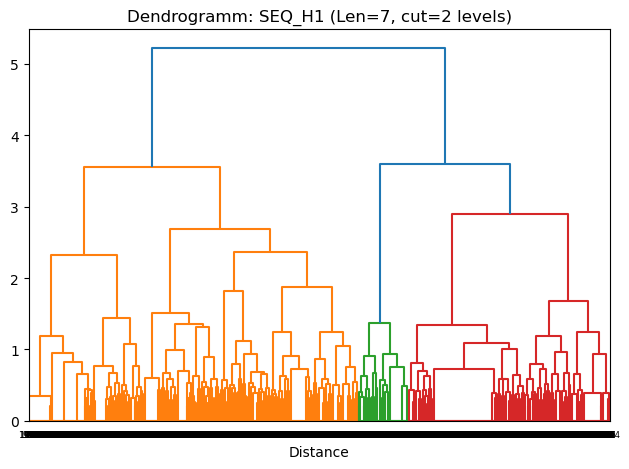


SEQ_H1, Länge 7 → 3 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 97x
      spike protein s1: 63x
      hemagglutinin: 16x
      neuraminidase: 12x
      envelope glycoprotein e2: 10x
      surface glycoprotein: 9x
      fusion glycoprotein f0: 8x
      gametocyte surface protein p230: 7x
      envelope glycoprotein gp160: 7x
      clade a/e 93th057 hiv-1 gp120 core: 7x
      circumsporozoite protein: 7x
      ch848.10.17 gp120: 6x
      envelope glycoprotein b: 6x
      receptor tyrosine-protein kinase erbb-2: 6x
      leukocyte surface antigen cd47: 5x
      outer surface protein a: 5x
      reticulocyte binding protein 2b: 5x
      programmed cell death protein 1: 4x
      proprotein convertase subtilisin/kexin type 9: 4x
      25 kda ookinete surface antigen: 4x
      interleukin-1 beta: 4x
      envelope protein: 4x
      envelope glycoprotein gp120: 4x
      spike glycoprotein,fibritin: 4x
      tumor necrosis factor receptor superfamily member 10b: 

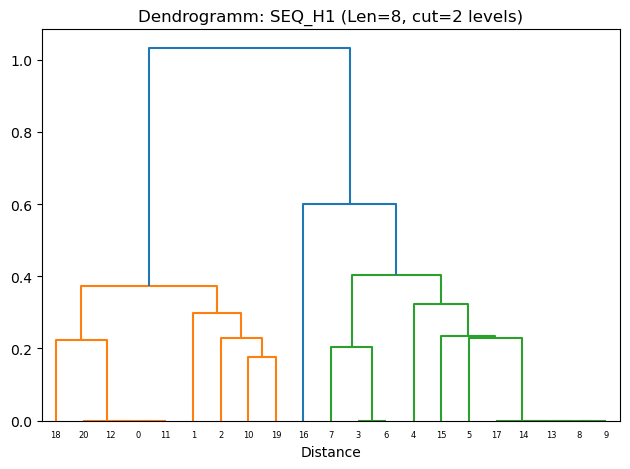


SEQ_H1, Länge 8 → 3 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 2x
      envelope glycoprotein gp160: 1x
      genome polyprotein: 1x
      glutamate receptor ionotropic, nmda 1: 1x
      isoform 2b of gtpase kras: 1x
      25 kda ookinete surface antigen: 1x
      pfs25: 1x
      hemagglutinin: 1x
    PDBs:
      7wph
      6dfh
      5gzo
      8vuj
      7mdp
      8x0y
      8ezk
      6b0h
      4xnm
    Sequenzen:
      GGSISSNN
      GGSISSSN
      GGSISSSN
      GGSISSSN
      GGSISSSN
      GASISSGD
      GFSISSSY
      GGSISSSH
      GGSISSSY
  Cluster 2:
    Antigen-Verteilung:
      envelope glycoprotein gp120: 1x
    PDBs:
      7kde
    Sequenzen:
      GYNIRSNN
  Cluster 3:
    Antigen-Verteilung:
      ige fc: 3x
      hemagglutinin ha1 chain: 1x
      isoform 2b of gtpase kras: 1x
      spike protein s1: 1x
      spike glycoprotein: 1x
      immunoglobulin heavy constant epsilon: 1x
      gametocyte surface protein p230: 1x
      non-struc

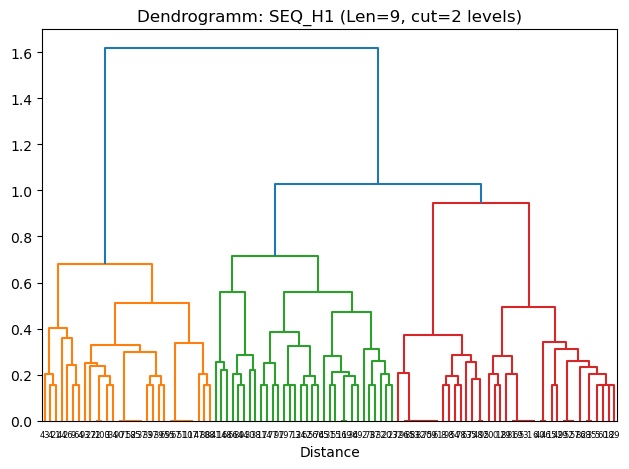


SEQ_H1, Länge 9 → 3 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 11x
      spike protein s1: 4x
      hemagglutinin: 2x
      interleukin-13: 2x
      mhc class i antigen: 1x
      rna polymerase sigma factor: 1x
      protein-glutamine gamma-glutamyltransferase e: 1x
      spike protein s2': 1x
      reverse transcriptase p51: 1x
      interleukin-1 beta: 1x
      de novo design 4e1h_95: 1x
      interleukin-6: 1x
      envelope glycoprotein b: 1x
      fusion glycoprotein f0: 1x
      de novo designed protein 4h_01: 1x
    PDBs:
      8erq
      8t6m
      8vye
      7wrj
      8tma
      9bdf
      7wee
      3lev
      7ycy
      8gdr
      4ps4
      8rmx
      7yvk
      7lss
      7cm4
      7d0d
      8hp9
      7xsa
      7yve
      7t01
      6vug
      7mmo
      4g6m
      6urm
      6ywc
      8ywq
      8rgz
      8cw9
      6ywd
      3l5x
    Sequenzen:
      GFSVTTSGV
      GFSVNTSGV
      GFSVNTGGV
      GFSLKKNGV
      GGSFATENY
      G

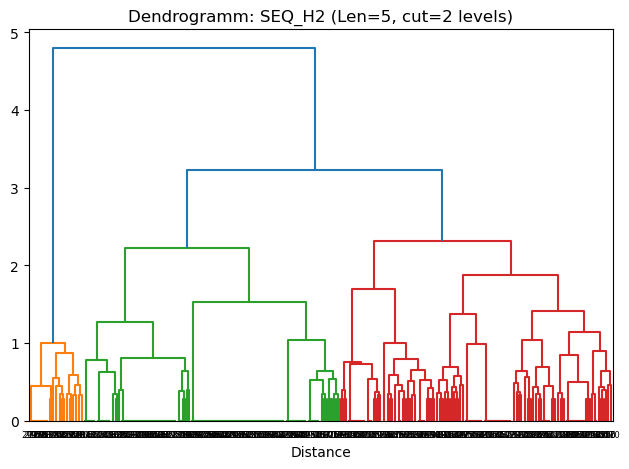


SEQ_H2, Länge 5 → 3 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 10x
      spike protein s1: 4x
      interleukin-13: 2x
      de novo design 4e1h_95: 1x
      rna polymerase sigma factor: 1x
      envelope glycoprotein b: 1x
      carbonic anhydrase 12: 1x
      spike protein s2': 1x
      mhc class i antigen: 1x
      cytotoxic t-lymphocyte protein 4: 1x
      de novo designed protein 4h_01: 1x
      interleukin-1 beta: 1x
      fusion glycoprotein f0: 1x
      hemagglutinin: 1x
      protein-glutamine gamma-glutamyltransferase e: 1x
      interleukin-6: 1x
      reverse transcriptase p51: 1x
    PDBs:
      7t01
      7lss
      7mmo
      7d0d
      6ywc
      8erq
      7xsa
      7yvk
      7yve
      8gdr
      7ycy
      7wrj
      3lev
      8rgz
      7wee
      6rps
      8vye
      8hp9
      8t6m
      6xy2
      3l5x
      4ps4
      6ywd
      4g6m
      8cw9
      6urm
      7cm4
      8rmx
      8ywq
      6vug
    Sequenzen:
      YWDDD


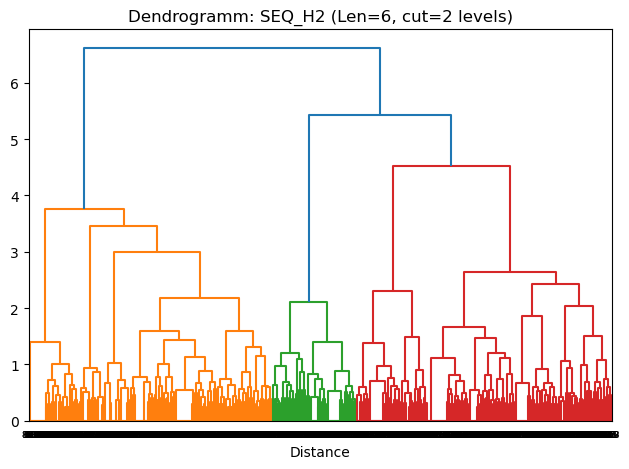


SEQ_H2, Länge 6 → 3 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 58x
      spike protein s1: 47x
      hemagglutinin: 11x
      circumsporozoite protein: 10x
      programmed cell death protein 1: 8x
      gametocyte surface protein p230: 8x
      reticulocyte binding protein 2b: 4x
      interleukin-17a: 4x
      fusion glycoprotein f0: 4x
      receptor tyrosine-protein kinase erbb-3: 3x
      tumor necrosis factor receptor superfamily member 9: 3x
      maltose-binding periplasmic protein: 3x
      histone chaperone asf1: 3x
      clade a/e 93th057 hiv-1 gp120 core: 3x
      surface glycoprotein: 3x
      factor h binding protein: 2x
      erythropoietin receptor: 2x
      env: 2x
      programmed cell death 1 ligand 1: 2x
      t-cell immunoglobulin mucin receptor 3: 2x
      t-cell immunoreceptor with ig and itim domains: 2x
      major capsid protein: 2x
      spike protein: 2x
      hemagglutinin-neuraminidase: 2x
      envelope glycoprotein h: 2x


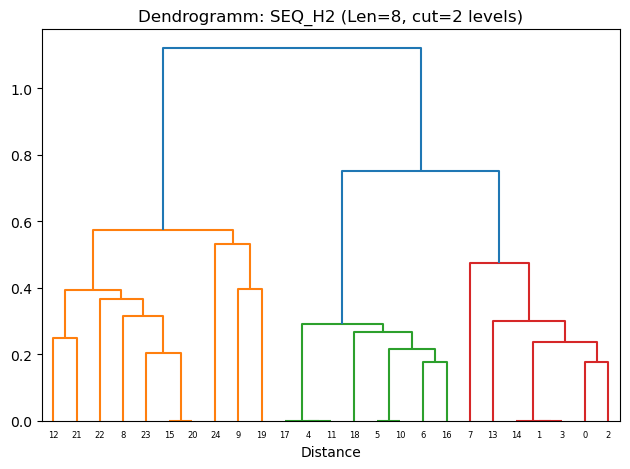


SEQ_H2, Länge 8 → 3 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 2x
      envelope glycoprotein h: 1x
      vitamin k-dependent protein c heavy chain: 1x
      interleukin-6: 1x
      transforming growth factor beta-3: 1x
      processed angiotensin-converting enzyme 2: 1x
      leukemia inhibitory factor: 1x
      spike protein s1: 1x
      tumor necrosis factor: 1x
    PDBs:
      7s07
      6m3c
      4cni
      8v52
      7e7e
      7ls9
      7kzb
      7n0a
      8sdg
      4g3y
    Sequenzen:
      RNKENSFT
      RLKSNNYE
      RNKNYQYG
      VSKTYNYA
      RNKANDYT
      RNKANSYT
      RNKANSYT
      KAKSDDYA
      SSNVNNDA
      RSKSINSA
  Cluster 2:
    Antigen-Verteilung:
      spike glycoprotein: 4x
      spike protein s1: 2x
      gn: 1x
      spike protein s2': 1x
    PDBs:
      7jx3
      8wsp
      7x8y
      7ey5
      8suo
      8ekd
      8r8k
      7mzj
    Sequenzen:
      KSKTDGGT
      KSKTDGGT
      KSKTDGGT
      KSKADGQT
      K

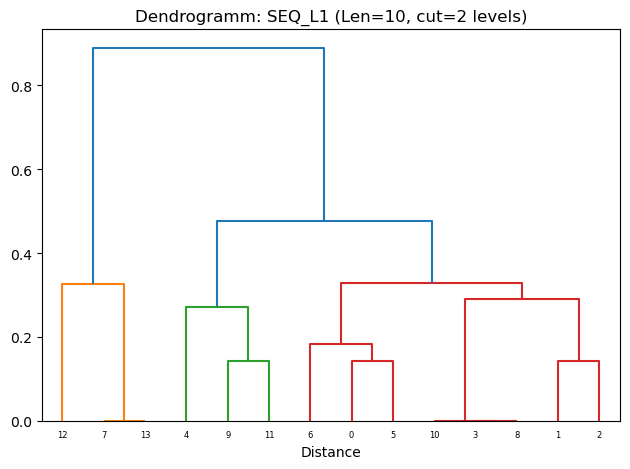


SEQ_L1, Länge 10 → 3 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      clade a/e 93th057 hiv-1 gp120 core: 1x
      hiv-1 clade a q842.d12 gp120: 1x
      hiv-1 yu2 gp120: 1x
    PDBs:
      4jb9
      4rx4
      4rwy
    Sequenzen:
      RASQGGNSLN
      RASQGLNFVV
      RASQGLNFVV
  Cluster 2:
    Antigen-Verteilung:
      serine protease htra1: 1x
      de novo designed protein 4h_01: 1x
      processed angiotensin-converting enzyme 2: 1x
    PDBs:
      7sjn
      6ywd
      7e7e
    Sequenzen:
      RASSSVEFIH
      SASSRVGYMH
      RASSSVRYMH
  Cluster 3:
    Antigen-Verteilung:
      interleukin-2 receptor subunit alpha: 1x
      b-lymphocyte antigen cd20: 1x
      h(+)/cl(-) exchange transporter clca: 1x
      natural cytotoxicity triggering receptor 3 ligand 1: 1x
      gametocyte surface protein p230: 1x
      tumor necrosis factor receptor superfamily member 10b: 1x
      pcrv: 1x
      sialic acid-binding ig-like lectin 8: 1x
    PDBs:
      3nfp
      8vgn
      2fed

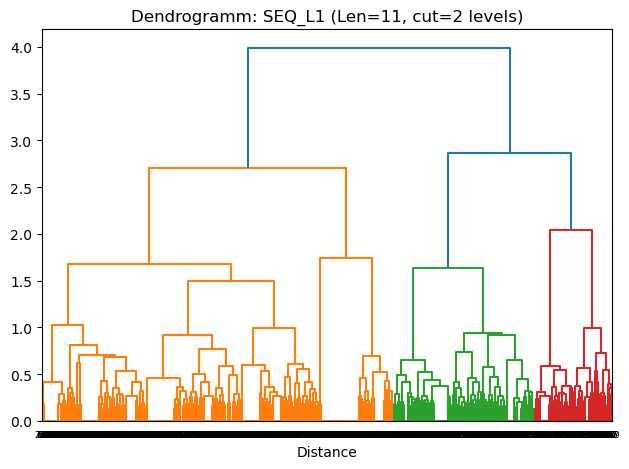


SEQ_L1, Länge 11 → 3 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 57x
      spike protein s1: 56x
      neuraminidase: 12x
      hemagglutinin: 12x
      surface glycoprotein: 10x
      programmed cell death protein 1: 8x
      gametocyte surface protein p230: 7x
      interleukin-1 beta: 6x
      proprotein convertase subtilisin/kexin type 9: 5x
      receptor tyrosine-protein kinase erbb-2: 5x
      circumsporozoite protein: 4x
      glycoprotein c: 4x
      outer surface protein a: 4x
      epidermal growth factor receptor: 3x
      spike protein: 3x
      tyrosine-protein phosphatase non-receptor type substrate 1: 3x
      envelope glycoprotein gp160: 3x
      envelope glycoprotein e2: 3x
      adp-ribosyl cyclase/cyclic adp-ribose hydrolase 1: 3x
      leukocyte surface antigen cd47: 3x
      clade a/e 93th057 hiv-1 gp120 core: 3x
      nucleoprotein: 3x
      tumor necrosis factor receptor superfamily member 10b: 3x
      vascular endothelial growth

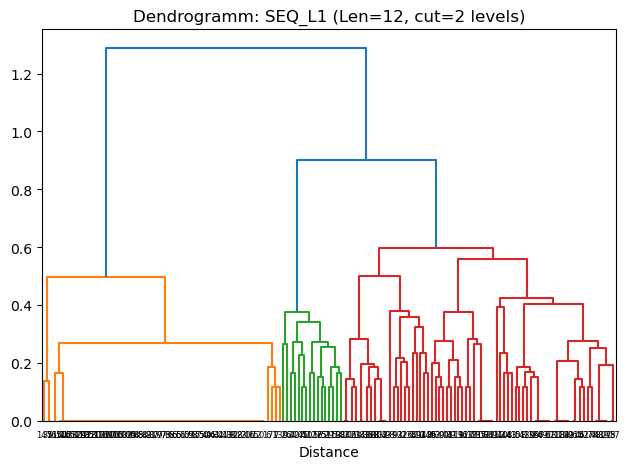


SEQ_L1, Länge 12 → 3 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 18x
      spike glycoprotein: 17x
      surface glycoprotein: 3x
      interleukin-1 receptor-like 2: 1x
      neuropilin-2: 1x
      toxin b: 1x
      s protein: 1x
      t-cell immunoreceptor with ig and itim domains: 1x
      sars-cov-2 spike glycoprotein: 1x
      factor h binding protein: 1x
      circumsporozoite protein: 1x
      pre-glycoprotein polyprotein gp complex: 1x
      hepatitis a virus cellular receptor 2: 1x
      immunoglobulin g-binding protein g (domain iii): 1x
      4e10 epitope scaffold t117: 1x
      v-type immunoglobulin domain-containing suppressor of t-cell activation : 1x
      interleukin-17a: 1x
      major pollen allergen bet v 1-a: 1x
      nucleoprotein: 1x
      mhc class i chain-related protein a: 1x
      outer surface protein a: 1x
      core protein: 1x
      ciliary neurotrophic factor receptor subunit alpha: 1x
      envelope glycoprotein e2: 1x
     

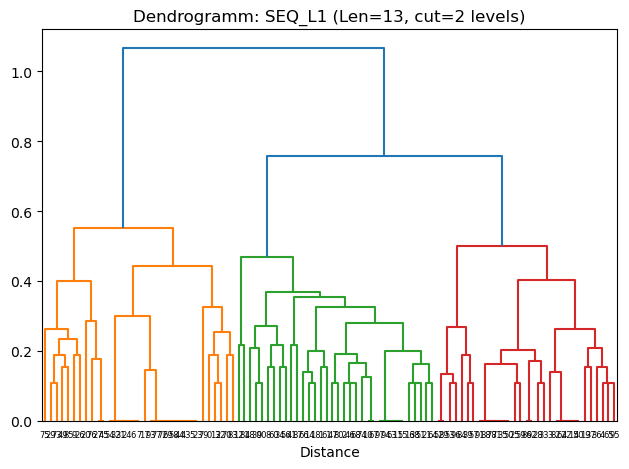


SEQ_L1, Länge 13 → 3 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 8x
      spike protein s1: 7x
      interleukin-17a: 2x
      hemagglutinin: 2x
      envelope glycoprotein gp120: 1x
      pfmsp1-19: 1x
      transforming growth factor beta-1 proprotein: 1x
      programmed cell death 1 ligand 1: 1x
      interleukin 15: 1x
      sars-cov-2 spike glycoprotein: 1x
      spike glycoprotein,fibritin,expression tag: 1x
      protein-glutamine gamma-glutamyltransferase e 27 kda non-catalytic chain : 1x
      interleukin-2: 1x
      glutamate receptor ionotropic, nmda 1: 1x
      envelope glycoprotein gp140: 1x
      stem_mimetic_01: 1x
      receptor tyrosine-protein kinase erbb-2: 1x
      1fd6 16055 v1v2 scaffold: 1x
    PDBs:
      7kde
      7u0x
      7m7b
      7mzk
      6xqw
      8udz
      7xsb
      7yds
      2xqb
      8dy1
      2vxs
      7jva
      7ycn
      7yck
      7vzt
      8zhe
      8zho
      8oxv
      6ii4
      5utz
      7ttx
   

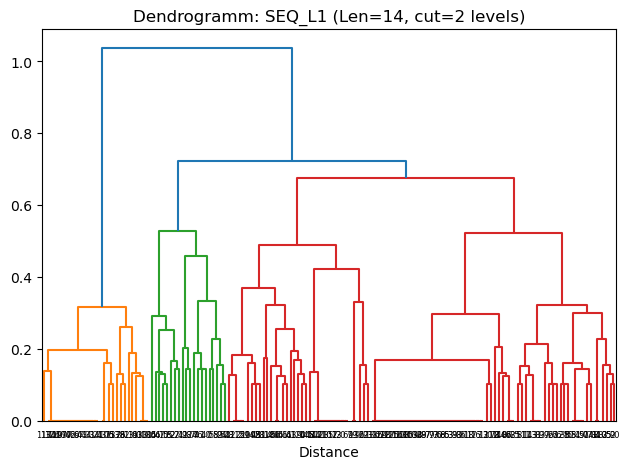


SEQ_L1, Länge 14 → 3 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 7x
      spike protein s1: 7x
      lysozyme c: 3x
      hemagglutinin: 2x
      low affinity immunoglobulin gamma fc region receptor ii-b: 1x
      imv membrane protein: 1x
      ig epsilon chain c region: 1x
      fusion glycoprotein f0: 1x
      structurally designed hmpv f protein hmpv_v3b_d12_ds454,fibritin : 1x
      envelope polyprotein: 1x
      vitamin k-dependent protein c heavy chain: 1x
      polcalcin phl p 7: 1x
      rsv fusion protein: 1x
    PDBs:
      6ii9
      7laa
      5occ
      5ush
      7dx4
      5anm
      7m6h
      7cho
      7wp0
      7tjq
      8csj
      7yh6
      8f6x
      8zho
      8siq
      8ahn
      7m6f
      3whe
      6m3b
      5otj
      8hrd
      8dzw
      8y4c
      8gdr
      7wqv
      4tsa
      4ttd
      4tsb
    Sequenzen:
      TGSSSNIGAGFDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      

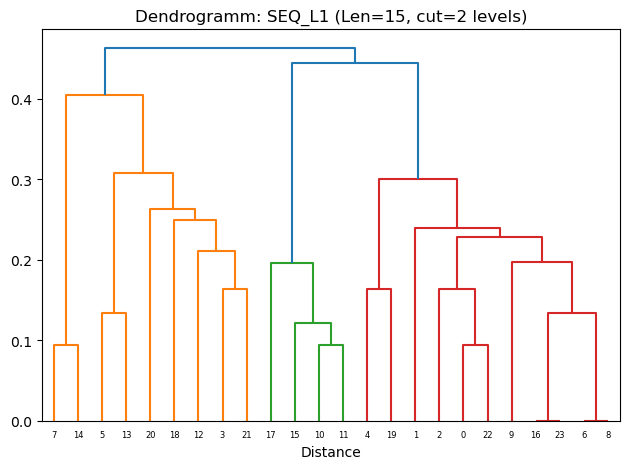


SEQ_L1, Länge 15 → 3 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      interferon alpha-2: 1x
      cd40 ligand: 1x
      spike glycoprotein: 1x
      non-structural protein 1: 1x
      25 kda ookinete surface antigen: 1x
      ige fc: 1x
      programmed cell death protein 1: 1x
      guanylyl cyclase c: 1x
      b-lymphocyte antigen cd19: 1x
    PDBs:
      4z5r
      1i9r
      7mw6
      7bsc
      6phc
      7shz
      5ggs
      8ghp
      6al5
    Sequenzen:
      RASQSVSTSSYSYMH
      RASQRVSSSTYSYMH
      RASESVEYYGTSLMQ
      RASESVEYSGTSLMH
      RSSQSLLHNGYNYLD
      RASKPVDGEGDSYLN
      RASKGVSTSGYSYLH
      RASESVDYYGSSLLQ
      KASQSVDYSGDSYLN
  Cluster 2:
    Antigen-Verteilung:
      immunoglobulin heavy constant epsilon: 2x
      ige fc: 2x
    PDBs:
      6eyo
      7shu
      7shy
      7si0
    Sequenzen:
      KASQSVDYDGDTYMN
      RASKSVDSDGDSYMN
      RASQSVDYDGDSYMN
      RASQSVDSDGDSYMN
  Cluster 3:
    Antigen-Verteilung:
      spike glycoprotein: 2x
 

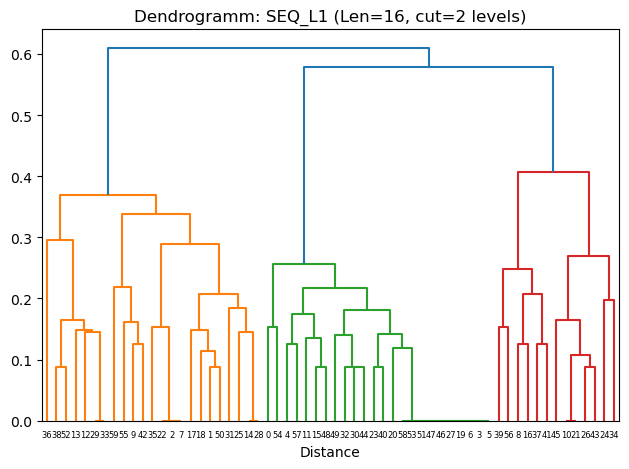


SEQ_L1, Länge 16 → 3 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      leukocyte surface antigen cd47: 2x
      hemagglutinin: 2x
      interleukin-17a: 1x
      ecd: 1x
      tumor necrosis factor receptor superfamily member 5: 1x
      human t-cell receptor beta chain trbc2: 1x
      human a6 t-cell receptor beta chain trbc1: 1x
      er membrane protein complex subunit 1: 1x
      epidermal growth factor receptor: 1x
      protein opg190: 1x
      toxin b: 1x
      hla-a*02: 1x
      cytotoxic t-lymphocyte protein 4: 1x
      envelope glycoprotein b: 1x
      t-cell immunoreceptor with ig and itim domains: 1x
      spike protein s1: 1x
      spike glycoprotein: 1x
      25 kda ookinete surface antigen: 1x
      fusion glycoprotein f0: 1x
      c-x-c chemokine receptor type 4: 1x
      envelope glycoprotein e2: 1x
    PDBs:
      5tzt
      7wkx
      6o9i
      8yx9
      8toa
      7amr
      7amq
      7kra
      4uv7
      8xs3
      7so5
      5iwl
      8eb2
      9dq5
  

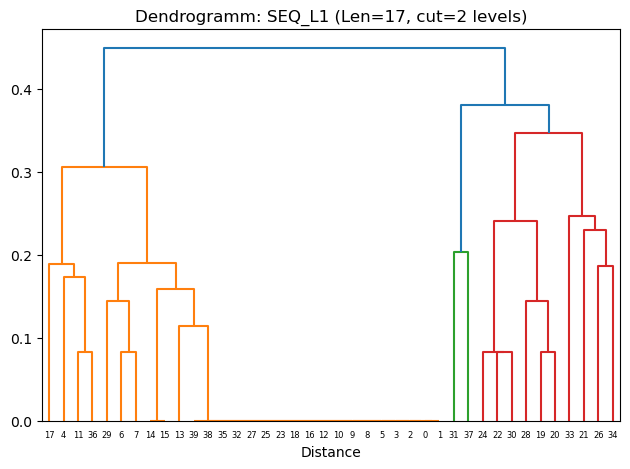


SEQ_L1, Länge 17 → 3 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 7x
      spike protein s1: 5x
      surface glycoprotein: 2x
      gametocyte surface protein p230: 2x
      hiv-1 clade ae gp120 core: 1x
      spike protein s2': 1x
      cd9 antigen: 1x
      interleukin-27 subunit alpha: 1x
      interleukin-2 receptor subunit alpha: 1x
      activin receptor type-2b: 1x
      germline-targeting hiv-1 gp120 engineered outer domain eod-gt8 : 1x
      4f2 cell-surface antigen heavy chain: 1x
      gremlin-1: 1x
      t-cell-specific surface glycoprotein cd28: 1x
      protein-glutamine gamma-glutamyltransferase e: 1x
      hemagglutinin: 1x
    PDBs:
      6bf4
      8ekd
      8d48
      7eng
      7prz
      8gf2
      8cwj
      6rlo
      7mzk
      7zxk
      7f9w
      7kn3
      7oly
      5if0
      7k9z
      7czy
      7d0d
      7ps2
      7czx
      7df1
      7uvs
      7ubs
      8dnn
      8b7h
      8suo
      8s6z
      8rmx
      8ume
  

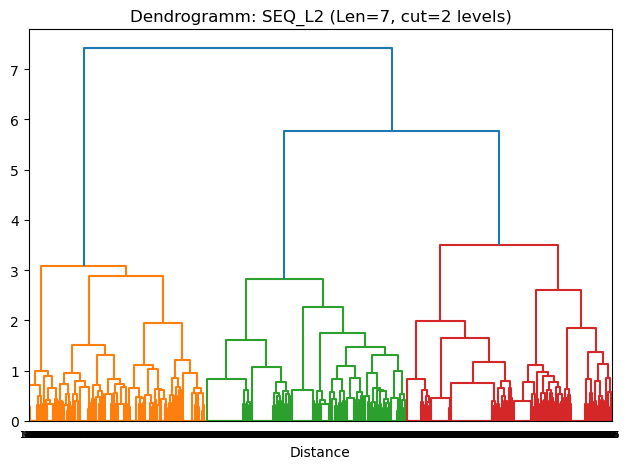


SEQ_L2, Länge 7 → 3 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 70x
      spike protein s1: 60x
      hemagglutinin: 16x
      fusion glycoprotein f0: 9x
      neuraminidase: 7x
      surface glycoprotein: 5x
      circumsporozoite protein: 5x
      reticulocyte binding protein 2b: 5x
      envelope glycoprotein gp120: 5x
      envelope glycoprotein b: 5x
      ch848.10.17 gp120: 5x
      spike glycoprotein,fibritin: 4x
      25 kda ookinete surface antigen: 4x
      gametocyte surface protein p230: 4x
      hemagglutinin ha1 chain: 3x
      interleukin-17a: 3x
      erythropoietin receptor: 3x
      envelope protein: 3x
      envelope glycoprotein gp160: 3x
      ch848.10.17.sosip gp120: 3x
      sars-cov-2 spike glycoprotein: 3x
      lysozyme c: 3x
      conglutin: 2x
      receptor binding protein: 2x
      duffy binding surface protein region ii: 2x
      thyrotropin receptor: 2x
      reticulocyte-binding protein homolog 5: 2x
      hemagglutinin h

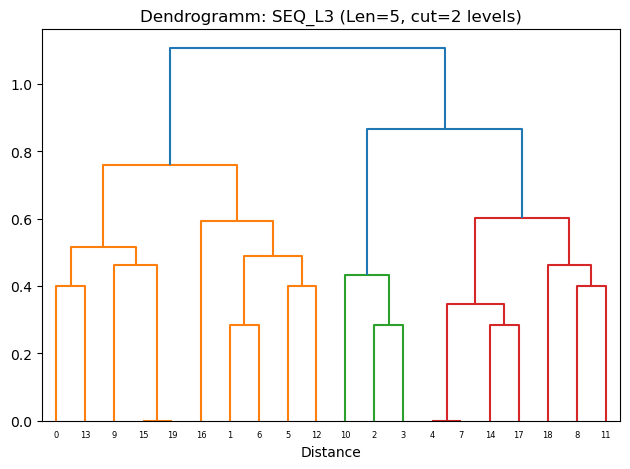


SEQ_L3, Länge 5 → 3 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 2x
      germline-targeting hiv-1 gp120 engineered outer domain eod-gt8 : 1x
      glycoprotein 120: 1x
      interleukin-13 receptor subunit alpha-1: 1x
      envelope glycoprotein gp160: 1x
      envelope protein ul128: 1x
      spike protein s1: 1x
      hemagglutinin: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
    PDBs:
      9cci
      5if0
      7rdw
      4hwb
      4j6r
      7m30
      8qh0
      6e4x
      7s6j
      5te6
    Sequenzen:
      QQYDA
      QQYYS
      QHMYT
      QQYET
      QQYET
      QQLNN
      QQGVT
      QQQGT
      QQPLT
      QVLQF
  Cluster 2:
    Antigen-Verteilung:
      envelope glycoprotein gp140: 1x
      bg505-sosip.v4.1-gt1.2gp120: 1x
      envelope glycoprotein gp120: 1x
    PDBs:
      6b0n
      8e1p
      7ugq
    Sequenzen:
      NAYEF
      SSYEF
      SAFEY
  Cluster 3:
    Antigen-Verteilung:
      426c ds-sosip d3: 1x
      426c.tm4delta

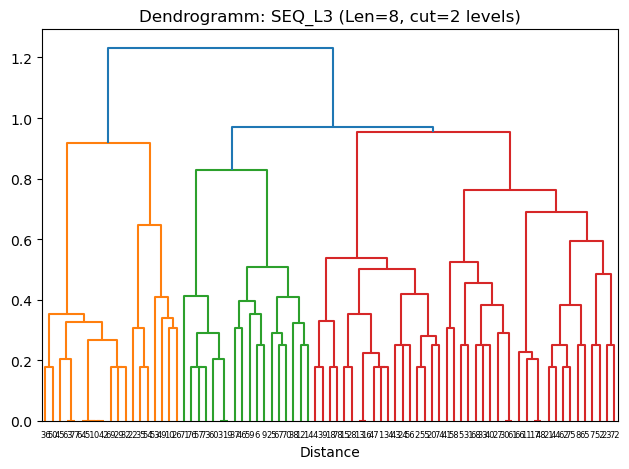


SEQ_L3, Länge 8 → 3 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 3x
      spike protein s1: 2x
      integrin alpha-l: 1x
      glycoprotein g: 1x
      surface glycoprotein: 1x
      envelope glycoprotein d: 1x
      envelope glycoprotein e2: 1x
      gna2132: 1x
      polyprotein: 1x
      mhc class i chain-related protein a: 1x
      fusion glycoprotein f0: 1x
      hemagglutinin ha1: 1x
      hepatitis a virus cellular receptor 2: 1x
      envelope glycoprotein gp160: 1x
      alpha-hemolysin: 1x
      reticulocyte-binding protein homolog 5: 1x
    PDBs:
      3hi6
      7ljr
      6cmg
      7ps1
      7n62
      3w9e
      6uyg
      9l6c
      5o1r
      6bkd
      7ul1
      7s7i
      8eay
      5w08
      6txz
      5t3z
      4u6v
      8pwv
      7y6l
    Sequenzen:
      QQSYSTPS
      QQYSSSRT
      QQYGRSPS
      QQYGSSPL
      QQYGSSPL
      QQYGSSPT
      QQYGSSPT
      QQYGSSPT
      QQSYGSPT
      QQYGLSST
      QQYGSSYT
      QQYGSSFT


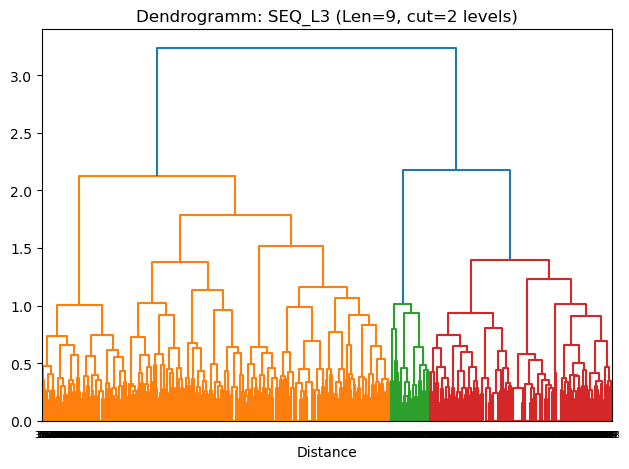


SEQ_L3, Länge 9 → 3 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 67x
      spike protein s1: 51x
      hemagglutinin: 23x
      fusion glycoprotein f0: 9x
      surface glycoprotein: 6x
      programmed cell death protein 1: 6x
      gametocyte surface protein p230: 5x
      receptor tyrosine-protein kinase erbb-2: 5x
      interleukin-1 beta: 5x
      envelope glycoprotein e2: 5x
      epidermal growth factor receptor: 5x
      leukocyte surface antigen cd47: 5x
      gametocyte surface protein p45/48: 4x
      spike protein s2': 4x
      clade a/e 93th057 hiv-1 gp120 core: 3x
      tumor necrosis factor receptor superfamily member 5: 3x
      adp-ribosyl cyclase/cyclic adp-ribose hydrolase 1: 3x
      outer surface protein a: 3x
      cytotoxic t-lymphocyte protein 4: 3x
      envelope glycoprotein h: 3x
      envelope glycoprotein b: 3x
      iron-regulated surface determinant protein b: 3x
      genome polyprotein: 3x
      hepatocyte growth factor re

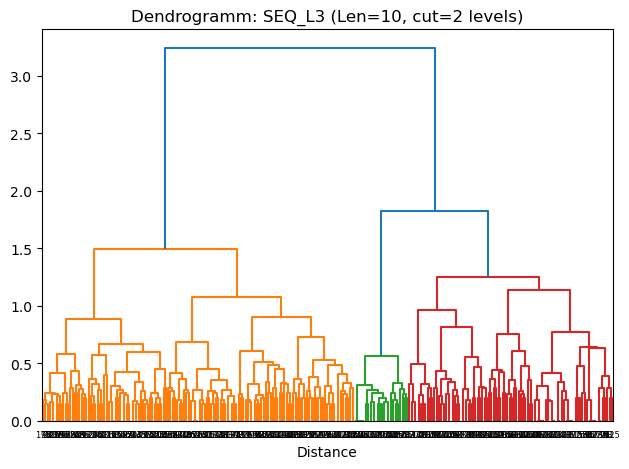


SEQ_L3, Länge 10 → 3 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 27x
      spike glycoprotein: 22x
      neuraminidase: 10x
      gametocyte surface protein p230: 6x
      surface glycoprotein: 5x
      hemagglutinin: 3x
      circumsporozoite protein: 2x
      hemagglutinin ha1: 2x
      maltose-binding periplasmic protein: 2x
      tyrosine-protein phosphatase non-receptor type substrate 1: 2x
      interleukin-17f: 1x
      thrombin heavy chain: 1x
      tumor necrosis factor: 1x
      cadmium and zinc efflux pump fief: 1x
      myeloid-derived growth factor: 1x
      leukocyte surface antigen cd47: 1x
      leukemia inhibitory factor: 1x
      v-type immunoglobulin domain-containing suppressor of t-cell activation : 1x
      activin receptor type-2b: 1x
      gp120, bg505 sosip.664 t332n: 1x
      leucine-rich repeat and immunoglobulin-like domain-containing nogo receptor-interacting protein 1 : 1x
      ara h 2 allergen: 1x
      interleukin-13: 1x
  

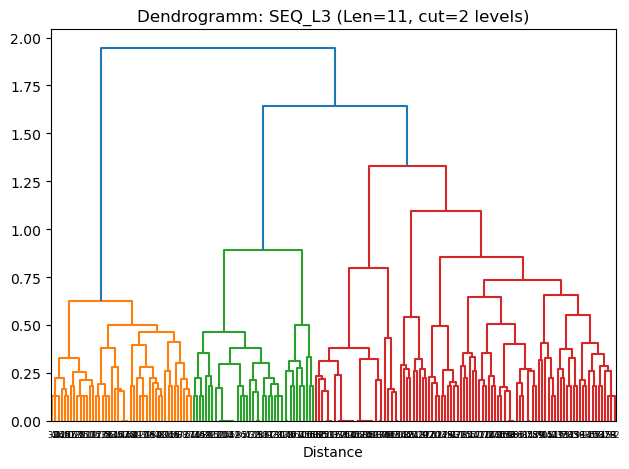


SEQ_L3, Länge 11 → 3 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 9x
      spike protein s1: 3x
      neuraminidase: 2x
      merozoite surface protein 1: 2x
      hemagglutinin: 2x
      capsid protein: 1x
      ig gamma-1 chain c region: 1x
      glycoprotein g: 1x
      pfmsp1-19: 1x
      phosphate-binding protein psts 1: 1x
      nucleoprotein: 1x
      mers-cov rbd: 1x
      stem_mimetic_01: 1x
      beta-mammal toxin cn2: 1x
      induced myeloid leukemia cell differentiation protein mcl-1homolog,induced myeloid leukemia cell differentiation protein mcl-1 : 1x
      erythropoietin receptor: 1x
      gametocyte surface protein p230: 1x
      receptor tyrosine-protein kinase erbb-3: 1x
      25 kda ookinete surface antigen: 1x
      surface glycoprotein: 1x
      low affinity immunoglobulin gamma fc region receptor ii-b: 1x
      rh5-34em: 1x
      envelope protein ul128: 1x
      envelopment polyprotein: 1x
      receptor binding protein: 1x
      d

In [17]:
#dendrogramm clustern
# nach längen






import csv
# Ausgabe-Ordner erstellen
os.makedirs("cdr_cluster_HC_length_tsvs", exist_ok=True)

# Parameter für Dendrogramm-Cut
levels_down = 2  # Anzahl der Ebenen für den Cut; etwa 2 = 3 Teilbäume

# Liste der 20 Standard-Aminosäuren
AA_LIST = list("ACDEFGHIKLMNPQRSTVWY")

def aa_freq_vector(seq: str) -> np.ndarray:
    """Berechnet den normierten Häufigkeitsvektor der 20 Standard-Aminosäuren."""
    counts = np.array([seq.count(aa) for aa in AA_LIST], dtype=float)
    return counts / len(seq)


# Hauptschleife: je Region und je Sequenzlänge separate Subgruppen

for region in regions:
    # Ermittle alle eindeutigen Sequenzlängen in dieser Region
    lengths = sorted(df[region].str.len().dropna().unique())

    for L in lengths:
        # Subset für die aktuelle Länge
        sub_df = df[df[region].str.len() == L].reset_index(drop=True) #drop=True sorgt dafür, dass der alte Index komplett verworfen wird und nicht als zusätzliche Spalte im DataFrame auftaucht
        seqs = sub_df[region].tolist()
        X = np.vstack([aa_freq_vector(s) for s in seqs])

        # Hierarchisches Clustering
        Z = linkage(X, method="ward", metric="euclidean")
        threshold = Z[-levels_down, 2] if levels_down <= Z.shape[0] else 0.0

        # Dendrogrammdaten ohne Plot für Farbzuordnung
        ddata = dendrogram(
            Z,
            labels=[str(i) for i in range(len(seqs))],
            color_threshold=threshold,
            no_plot=True
        )

        # Blatt-Farben extrahieren
        leaves = ddata['leaves']
        leaf_colors = ddata['leaves_color_list']
        leaf_color_map = dict(zip(leaves, leaf_colors))

        # Eindeutige Farben in Erscheinungsreihenfolge sammeln
        unique_colors = []
        for col in leaf_colors:
            if col not in unique_colors:
                unique_colors.append(col)
        color_cluster_map = {col: idx+1 for idx, col in enumerate(unique_colors)}

        # TSV-Einträge sammeln
        entries = []
        for col in unique_colors:
            cid = color_cluster_map[col]
            leaves_in_cluster = [leaf for leaf, c in leaf_color_map.items() if c == col]
            for leaf_idx in leaves_in_cluster:
                pdb_id = sub_df.iloc[leaf_idx]['pdb']
                entries.append((pdb_id, region, L, cid))

        # Schreibe TSV für Region und Länge
        tsv_file = f"cdr_cluster_HC_length_tsvs/clusters_{region}_len{L}.tsv"
        with open(tsv_file, 'w', newline='') as f:
            writer = csv.writer(f, delimiter='\t')
            writer.writerow(["pdb", "CDR", "Length", "Cluster_Label"])
            writer.writerows(entries)
        print(f"✅ TSV geschrieben: {tsv_file}")

        # Plot Dendrogramm        plt.figure(figsize=(8, 6))
        dendrogram(
            Z,
            labels=[str(i) for i in range(len(seqs))],
            color_threshold=threshold,
            leaf_rotation=0,
            leaf_font_size=6
        )
        plt.title(f"Dendrogramm: {region} (Len={L}, cut={levels_down} levels)")
        plt.xlabel("Distance")
        plt.tight_layout()
        plt.show()

        # Konsolenausgabe der Cluster-Inhalte
        print(f"\n{region}, Länge {L} → {len(unique_colors)} Subgruppen:")
        for col in unique_colors:
            cid = color_cluster_map[col]
            leaves_in_cluster = [leaf for leaf, c in leaf_color_map.items() if c == col]
            antigens = sub_df.loc[leaves_in_cluster, 'antigen_name']
            pdbs = sub_df.loc[leaves_in_cluster, 'pdb']
            seq_list = sub_df.loc[leaves_in_cluster, region]

            counts = Counter(antigens)
            print(f"  Cluster {cid}:")
            print("    Antigen-Verteilung:")
            for ag, cnt in counts.most_common():
                print(f"      {ag}: {cnt}x")
            print("    PDBs:")
            for p in pdbs:
                print(f"      {p}")
            print("    Sequenzen:")
            for s in seq_list:
                print(f"      {s}")
        print("\n" + "-"*50 + "\n")

In [19]:
import pandas as pd
import glob
import os

# Verzeichnis mit deinen TSV-Dateien
path = "cdr_cluster_HC_length_tsvs"
all_files = glob.glob(os.path.join(path, "*.tsv"))
# Wir gehen die einzelnen CDRs durch
cdrs = ["H1", "H2", "L1", "L2", "L3"]

for cdr in cdrs:
    # Dateien für die aktuelle CDR sammeln
    pattern = os.path.join(path, f"*{cdr}*.tsv")
    all_files = glob.glob(pattern)

    print(f"\nFür CDR {cdr} wurden gefunden: {len(all_files)} Dateien")
    
    dfs = []
    for file in all_files:
        print(f" - {file}")
        df = pd.read_csv(file, sep="\t")
        # Cluster-Spalte bauen
        df["cluster"] = df["CDR"].astype(str) + "_" + df["Length"].astype(str) + "_" + df["Cluster_Label"].astype(str)
        # Nur PDB_ID und cluster behalten
        df = df[["pdb", "cluster"]]
        dfs.append(df)

    if dfs:
        merged_df = pd.concat(dfs, ignore_index=True)
        # Speichern
        output_file = f"merged_clusters_{cdr}.csv"
        merged_df.to_csv(output_file, index=False)
        print(f"=> Datei gespeichert: {output_file} mit {len(merged_df)} Zeilen")
    else:
        print(f"=> Keine Dateien für CDR {cdr} gefunden.")



Für CDR H1 wurden gefunden: 11 Dateien
 - cdr_cluster_HC_length_tsvs\clusters_SEQ_H1_len10.tsv
 - cdr_cluster_HC_length_tsvs\clusters_SEQ_H1_len12.tsv
 - cdr_cluster_HC_length_tsvs\clusters_SEQ_H1_len13.tsv
 - cdr_cluster_HC_length_tsvs\clusters_SEQ_H1_len14.tsv
 - cdr_cluster_HC_length_tsvs\clusters_SEQ_H1_len16.tsv
 - cdr_cluster_HC_length_tsvs\clusters_SEQ_H1_len4.tsv
 - cdr_cluster_HC_length_tsvs\clusters_SEQ_H1_len5.tsv
 - cdr_cluster_HC_length_tsvs\clusters_SEQ_H1_len6.tsv
 - cdr_cluster_HC_length_tsvs\clusters_SEQ_H1_len7.tsv
 - cdr_cluster_HC_length_tsvs\clusters_SEQ_H1_len8.tsv
 - cdr_cluster_HC_length_tsvs\clusters_SEQ_H1_len9.tsv
=> Datei gespeichert: merged_clusters_H1.csv mit 1307 Zeilen

Für CDR H2 wurden gefunden: 3 Dateien
 - cdr_cluster_HC_length_tsvs\clusters_SEQ_H2_len5.tsv
 - cdr_cluster_HC_length_tsvs\clusters_SEQ_H2_len6.tsv
 - cdr_cluster_HC_length_tsvs\clusters_SEQ_H2_len8.tsv
=> Datei gespeichert: merged_clusters_H2.csv mit 1254 Zeilen

Für CDR L1 wurden gefun

In [ ]:
import pandas as pd

# Lade die Originaldatei
df = pd.read_csv("naiver_ansatz/ab_ag_canonical_forms.csv")  # oder .tsv falls notwendig

# CDR-Regionen definieren
cdrs = ["H1", "H2", "L1", "L2", "L3"]

# Mapping zwischen CF-Spalten und neuen HC-Spalten
cf_columns = [f"CF_{cdr}" for cdr in cdrs]
hc_columns = [f"HC_{cdr}" for cdr in cdrs]

# Lege neue HC-Spalten mit leeren Werten an
for hc_col in hc_columns:
    df[hc_col] = None

# Für jede CDR-Typ die passende Clusterdatei einlesen und zuordnen
for cdr in cdrs:
    cluster_df = pd.read_csv(f"cdr_cluster_HC_tsvs/clusters_SEQ_{cdr}.tsv", sep="\t")
    

    # Clusterdatei: PDB_ID | CDR | Cluster_Label
    cluster_map = dict(zip(cluster_df["PDB_ID"], cluster_df["Cluster_Label"]))

    # Neue Spalte füllen auf Basis der PDB_ID-Zuordnung
    df[f"HC_{cdr}"] = df["PDB_ID"].map(cluster_map)

# Speichern als neue Datei
df.to_csv("ab_ag_hierarchical_canonical_forms_nach_länge.csv", index=False)
print("Neue Datei erfolgreich erstellt: ab_ag_hierarchical_canonical_forms_nach_länge.csv")

In [ ]:
import pandas as pd

# Lade die Originaldatei
df = pd.read_csv("naiver_ansatz/ab_ag_canonical_forms.csv")  # ggf. anpassen auf .tsv

# CDR-Regionen definieren
cdrs = ["H1", "H2", "L1", "L2", "L3"]

# Lege neue Spalten an
for cdr in cdrs:
    df[f"HC_{cdr}"] = None

# Für jede CDR die passende Clusterdatei einlesen und zuordnen
for cdr in cdrs:
    # Lade die gemergte Cluster-Datei
    cluster_df = pd.read_csv(f"merged_clusters_{cdr}.csv")
    
    # Cluster-Datei: PDB_ID | cluster
    cluster_map = dict(zip(cluster_df["PDB_ID"], cluster_df["cluster"]))
    
    # Neue Spalte füllen auf Basis von PDB_ID
    df[f"HC_{cdr}"] = df["PDB_ID"].map(cluster_map)

# Speichern
df.to_csv("ab_ag_hierarchical_canonical_forms_nach_länge.csv", index=False)
print("✅ Neue Datei erfolgreich erstellt: ab_ag_hierarchical_canonical_forms_nach_länge.csv")


3
✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_H1_len7.tsv


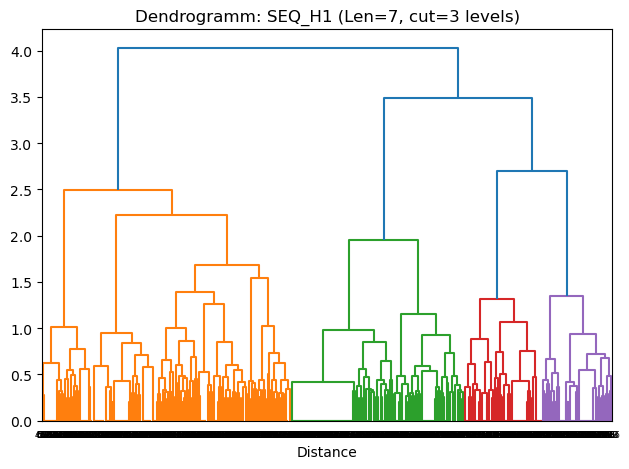


SEQ_H1, Länge 7 → 4 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 77x
      spike protein s1: 53x
      neuraminidase: 12x
      hemagglutinin: 12x
      envelope glycoprotein e2: 9x
      envelope glycoprotein gp160: 8x
      fusion glycoprotein f0: 7x
      gametocyte surface protein p230: 7x
      ch848.10.17 gp120: 7x
      surface glycoprotein: 6x
      clade a/e 93th057 hiv-1 gp120 core: 6x
      leukocyte surface antigen cd47: 6x
      receptor tyrosine-protein kinase erbb-2: 6x
      envelope glycoprotein b: 5x
      envelope glycoprotein gp120: 4x
      tumor necrosis factor receptor superfamily member 5: 4x
      hemagglutinin ha1: 4x
      ch848.10.17.sosip gp120: 4x
      envelope protein: 4x
      vascular endothelial growth factor a: 4x
      arginase-1: 3x
      spike protein s2': 3x
      t-cell immunoreceptor with ig and itim domains: 3x
      spike glycoprotein,fibritin: 3x
      programmed cell death protein 1: 3x
      25 kda ookinete s

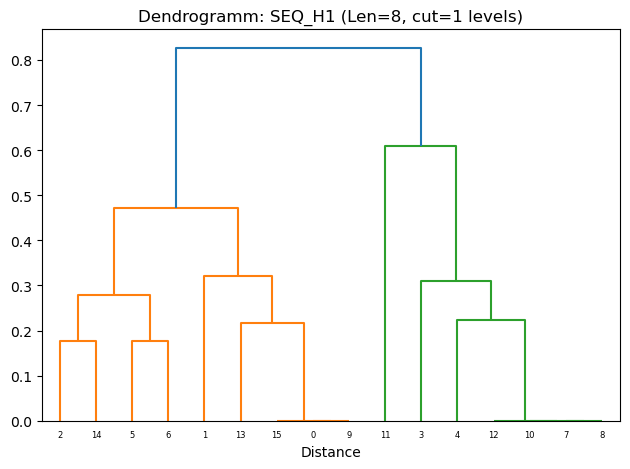


SEQ_H1, Länge 8 → 2 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 3x
      25 kda ookinete surface antigen: 1x
      hemagglutinin: 1x
      hemagglutinin ha1 chain: 1x
      envelope glycoprotein gp160: 1x
      glutamate receptor ionotropic, nmda 1: 1x
      genome polyprotein: 1x
    PDB_IDs:
      8ezk
      4xnm
      8dcc
      4m5z
      8x0y
      7wph
      6dfh
      8vuj
      5gzo
    Sequenzen:
      GFSISSSY
      GGSISSSY
      GYSISSGY
      GYSISSNY
      GASISSGD
      GGSISSNN
      GGSISSSN
      GGSISSSN
      GGSISSSN
  Cluster 2:
    Antigen-Verteilung:
      ige fc: 3x
      envelope glycoprotein gp120: 1x
      spike glycoprotein: 1x
      gametocyte surface protein p230: 1x
      neuraminidase: 1x
    PDB_IDs:
      7kde
      7xdl
      7uvq
      7shz
      6pzy
      7shy
      7si0
    Sequenzen:
      GYNIRSNN
      GYSFTSYY
      GYSITSDY
      GYSITSGY
      GYTISSGY
      GYSITSGY
      GYSITSGY

----------------------------

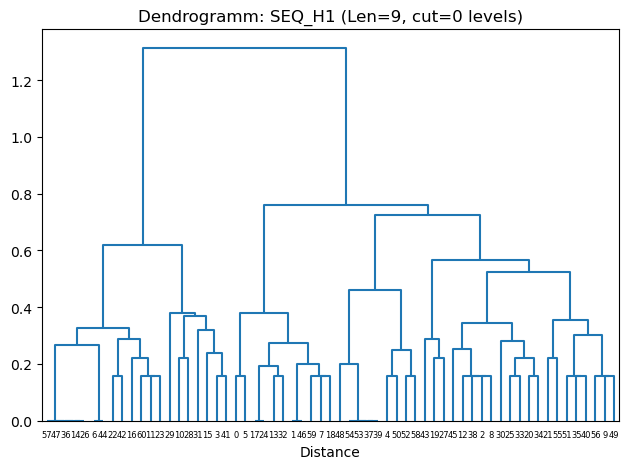


SEQ_H1, Länge 9 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 18x
      spike protein s1: 10x
      hemagglutinin: 10x
      neuraminidase: 5x
      surface glycoprotein: 4x
      epidermal growth factor receptor: 3x
      fusion glycoprotein f0: 2x
      spike protein s2': 1x
      envelope glycoprotein b: 1x
      pre-glycoprotein polyprotein gp complex: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      tumor necrosis factor receptor superfamily member 5: 1x
      envelope protein: 1x
      spike glycoprotein,fibritin: 1x
      envelope glycoprotein e: 1x
      e2 glycoprotein: 1x
    PDB_IDs:
      7lss
      7cm4
      7d0d
      8hp9
      7xsa
      8rgz
      6urm
      7yve
      7mmo
      7ycy
      7t01
      8gdr
      7yvk
      7wrj
      8vye
      8erq
      8cw9
      8tma
      9bdf
      7wee
      8veb
      8zho
      8tp6
      8eoo
      8cbd
      7bel
      8vef
      5w1k
      5kjr
      8yx1
      8tp7
      7pry
      7

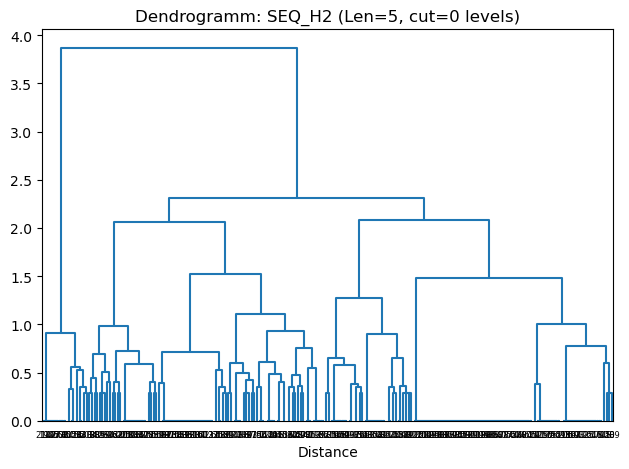


SEQ_H2, Länge 5 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 67x
      spike glycoprotein: 58x
      hemagglutinin: 23x
      surface glycoprotein: 14x
      neuraminidase: 8x
      fusion glycoprotein f0: 5x
      spike protein s2': 4x
      epidermal growth factor receptor: 4x
      nucleoprotein: 3x
      ige fc: 3x
      spike glycoprotein,fibritin: 3x
      gametocyte surface protein p230: 2x
      25 kda ookinete surface antigen: 2x
      envelope glycoprotein e: 2x
      envelope glycoprotein e2: 2x
      reticulocyte-binding protein homolog 5: 2x
      envelope glycoprotein b: 1x
      cytotoxic t-lymphocyte protein 4: 1x
      hemagglutinin ha1: 1x
      envelope glycoprotein h: 1x
      e2 glycoprotein: 1x
      glycoprotein 120: 1x
      programmed cell death 1 ligand 1: 1x
      tumor necrosis factor receptor superfamily member 5: 1x
      envelope protein e: 1x
      programmed cell death protein 1: 1x
      pre-glycoprotein polyprotein gp 

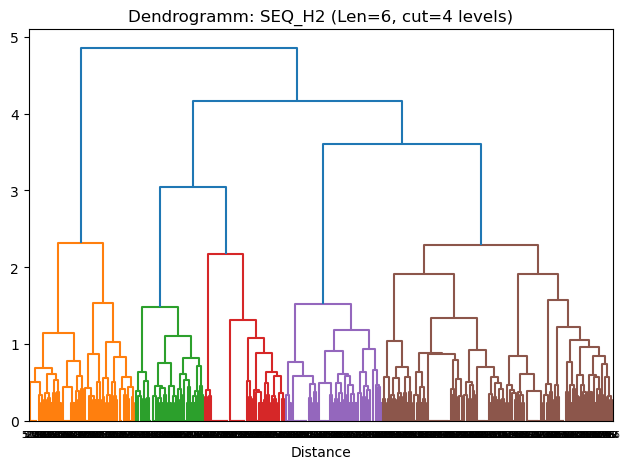


SEQ_H2, Länge 6 → 5 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 28x
      spike protein s1: 15x
      neuraminidase: 7x
      ch848.10.17 gp120: 7x
      envelope glycoprotein e2: 6x
      hemagglutinin: 4x
      spike glycoprotein,fibritin: 4x
      ch848.10.17.sosip gp120: 3x
      spike protein: 2x
      envelope glycoprotein gp120: 2x
      envelope glycoprotein gp160: 2x
      e2 glycoprotein: 2x
      fusion glycoprotein f0: 2x
      envelope protein: 1x
      programmed cell death 1 ligand 1: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      nucleoprotein: 1x
      reticulocyte-binding protein homolog 5: 1x
      transforming growth factor beta-2: 1x
      reticulocyte binding protein 2b: 1x
      interleukin-17a: 1x
      vascular endothelial growth factor a: 1x
      hemagglutinin ha1: 1x
      gametocyte surface protein p230: 1x
      tumor necrosis factor ligand superfamily member 13b: 1x
      surface glycoprotein: 1x
      envelope glyco

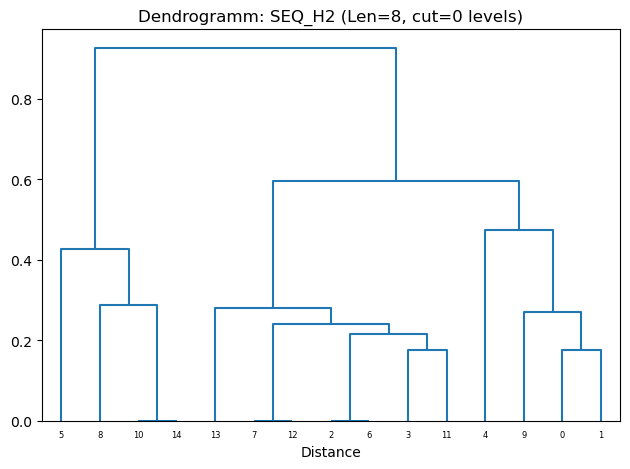


SEQ_H2, Länge 8 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 8x
      spike protein s1: 3x
      envelope glycoprotein h: 1x
      spike protein s2': 1x
      circumsporozoite protein: 1x
      hemagglutinin: 1x
    PDB_IDs:
      8sdg
      7s07
      7ls9
      7kzb
      7ey5
      7x8y
      7jx3
      8suo
      8ekd
      8r8k
      7mzj
      8khc
      6o2b
      8ghk
      8jmm
    Sequenzen:
      SSNVNNDA
      RNKENSFT
      RNKANSYT
      RNKANSYT
      KSKADGQT
      KSKTDGGT
      KSKTDGGT
      KSKIDGGT
      KSKIDGGT
      KSKADGGT
      KRKSDGGT
      SSEIGGGT
      RSKANGGR
      RTKGNSYA
      RSKAYGGT

--------------------------------------------------

0
✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_L1_len10.tsv


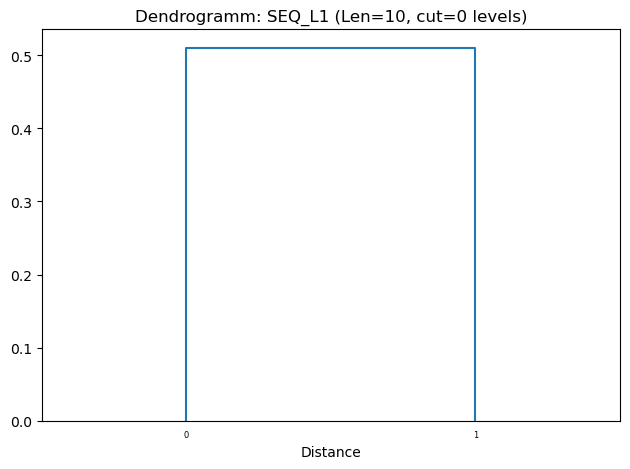


SEQ_L1, Länge 10 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      gametocyte surface protein p230: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
    PDB_IDs:
      7uvq
      4jb9
    Sequenzen:
      SASSSVSYMY
      RASQGGNSLN

--------------------------------------------------

1
✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_L1_len11.tsv


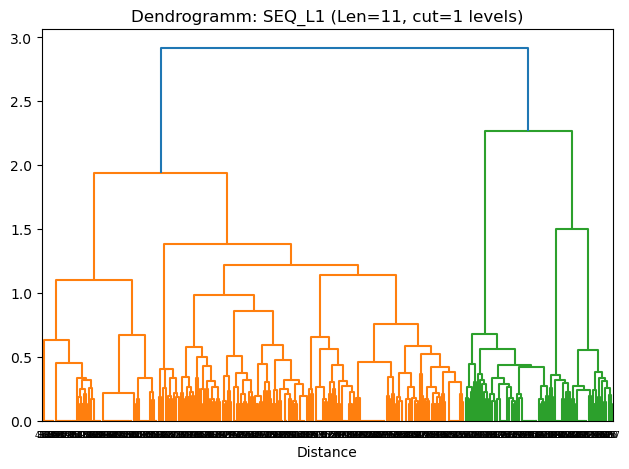


SEQ_L1, Länge 11 → 2 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 76x
      spike protein s1: 68x
      hemagglutinin: 17x
      neuraminidase: 14x
      surface glycoprotein: 11x
      programmed cell death protein 1: 9x
      gametocyte surface protein p230: 9x
      clade a/e 93th057 hiv-1 gp120 core: 6x
      envelope glycoprotein gp160: 6x
      envelope glycoprotein e2: 5x
      receptor tyrosine-protein kinase erbb-2: 5x
      fusion glycoprotein f0: 5x
      histone chaperone asf1: 4x
      spike protein: 4x
      circumsporozoite protein: 4x
      leukocyte surface antigen cd47: 4x
      nucleoprotein: 3x
      epidermal growth factor receptor: 3x
      envelope protein e: 3x
      e2 glycoprotein: 3x
      vascular endothelial growth factor a: 3x
      tyrosine-protein phosphatase non-receptor type substrate 1: 3x
      envelope glycoprotein b: 3x
      envelope glycoprotein e: 3x
      programmed cell death 1 ligand 1: 2x
      arginase-1: 2x
 

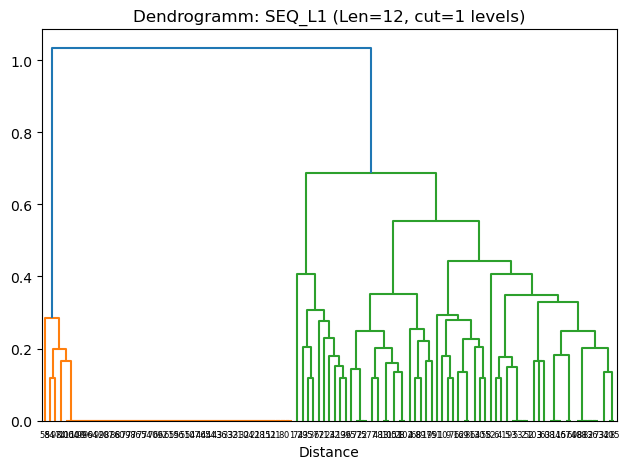


SEQ_L1, Länge 12 → 2 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 18x
      spike glycoprotein: 17x
      surface glycoprotein: 3x
      hemagglutinin: 1x
      t-cell immunoreceptor with ig and itim domains: 1x
      sars-cov-2 spike glycoprotein: 1x
      circumsporozoite protein: 1x
      pre-glycoprotein polyprotein gp complex: 1x
      interleukin-17a: 1x
      nucleoprotein: 1x
      envelope glycoprotein e2: 1x
      spike glycoprotein,fibritin: 1x
    PDB_IDs:
      7ej4
      5ibl
      7ps1
      7coe
      7n62
      6xe1
      7mzm
      7d0c
      7lab
      7r6x
      7k8m
      7vyt
      7lrt
      7bnv
      7l2f
      7n5h
      6o25
      7n3i
      7ljr
      7l7e
      7beo
      5w1k
      7ls9
      7tcc
      7x7o
      6wir
      7orb
      7jmo
      7str
      7zbu
      8dzh
      8dlw
      8dad
      7x25
      7ul1
      7s5r
      7ru4
      7s5q
      8gsb
      8bec
      8k5g
      8w0w
      8qrf
      9fgt
      8qh0
   

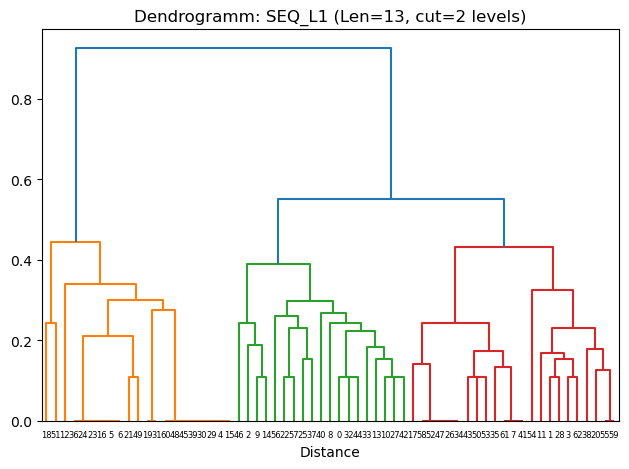


SEQ_L1, Länge 13 → 3 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 6x
      spike glycoprotein: 6x
      interleukin-17a: 2x
      hemagglutinin: 2x
      envelope glycoprotein gp120: 1x
      programmed cell death 1 ligand 1: 1x
      sars-cov-2 spike glycoprotein: 1x
      spike glycoprotein,fibritin,expression tag: 1x
      glutamate receptor ionotropic, nmda 1: 1x
    PDB_IDs:
      7xsb
      7kde
      7yds
      7jva
      7ycn
      7yck
      7vzt
      8zhe
      8zho
      7u0x
      7m7b
      8dy1
      2vxs
      6ii4
      7ttx
      7jx3
      6ii8
      7wog
      7wo4
      8vuj
      8eoo
    Sequenzen:
      TGSNGYIANNYVQ
      TGTSSNIENYHAF
      QSSQNVYSNNRLS
      TGSSGSIASNYVQ
      TGSSGSIASNYVQ
      TGSSGSIASNYVQ
      TGSSGSIASNYVQ
      TGSSGSIASNYVQ
      TGSSGSIASNYVQ
      TRNSGSIASNYVQ
      TGSSGNIASNYVQ
      TRSSGSLANYYVQ
      TRSSGSLANYYVQ
      TRSSGSIASNYVQ
      TRSSGSIASNYVQ
      TRSSGSIASNYVQ
      TRSSGSIASNYVQ
  

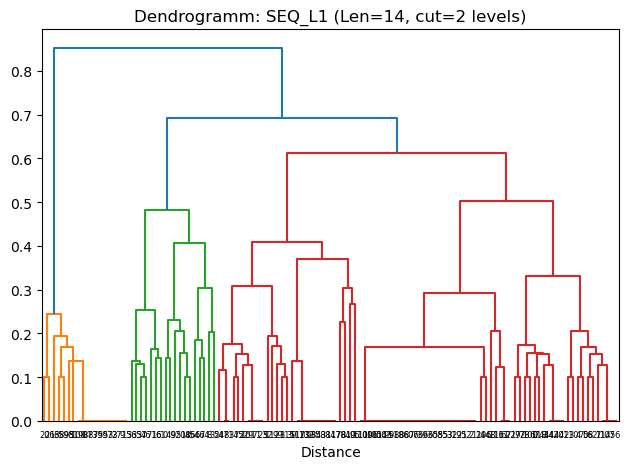


SEQ_L1, Länge 14 → 3 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 7x
      spike glycoprotein: 6x
      fusion glycoprotein f0: 2x
      hemagglutinin: 2x
      ig epsilon chain c region: 1x
    PDB_IDs:
      8hrd
      8e2u
      8gdr
      3whe
      7m6f
      6ii9
      7wqv
      7laa
      7dx4
      5anm
      7m6h
      7cho
      7wp0
      7tjq
      8csj
      7yh6
      8zho
      8siq
    Sequenzen:
      LGGSSNIGAGYDVH
      TGSGSNLGADYGVH
      SGTSRDIGGYNYVA
      TGSSSNIGAGYAVH
      TGSSSNIGAGYYVH
      TGSSSNIGAGFDVH
      TGNSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
      TGSSSNIGAGYDVH
  Cluster 2:
    Antigen-Verteilung:
      ch848.10.17 gp120: 4x
      spike glycoprotein: 2x
      envelope glycoprotein e: 2x
      ch848.10.17.sosip gp120: 1x
      spike pr

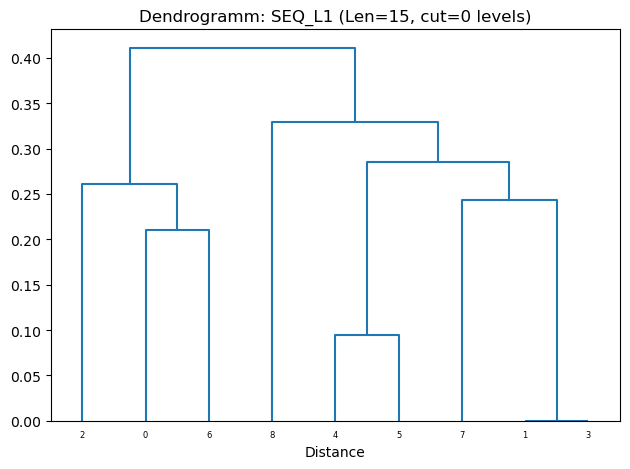


SEQ_L1, Länge 15 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 3x
      ige fc: 3x
      interferon alpha-2: 1x
      programmed cell death protein 1: 1x
      25 kda ookinete surface antigen: 1x
    PDB_IDs:
      4z5r
      7mw6
      5ggs
      6phc
      7shy
      7si0
      7shz
      7mw3
      7e5s
    Sequenzen:
      RASQSVSTSSYSYMH
      RASESVEYYGTSLMQ
      RASKGVSTSGYSYLH
      RSSQSLLHNGYNYLD
      RASQSVDYDGDSYMN
      RASQSVDSDGDSYMN
      RASKPVDGEGDSYLN
      RASESVDNYGISFMN
      RASESVDNYGISFMN

--------------------------------------------------

0
✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_L1_len16.tsv


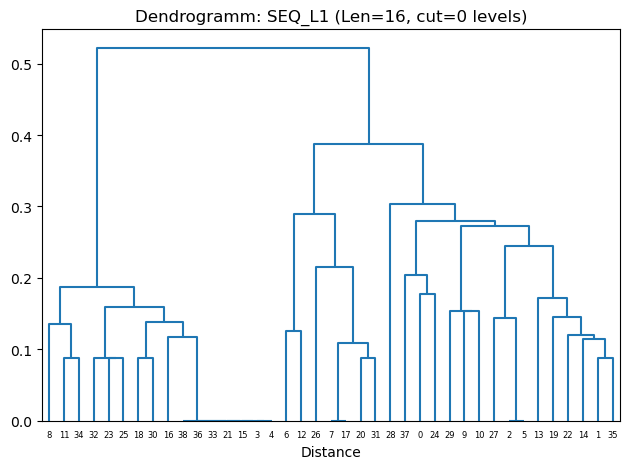


SEQ_L1, Länge 16 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 8x
      hemagglutinin: 7x
      spike protein s1: 4x
      fusion glycoprotein f0: 2x
      25 kda ookinete surface antigen: 2x
      leukocyte surface antigen cd47: 2x
      circumsporozoite protein: 1x
      envelope glycoprotein h: 1x
      spike protein: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      neuraminidase: 1x
      reticulocyte-binding protein homolog 5: 1x
      glycoprotein 120: 1x
      epidermal growth factor receptor: 1x
      interleukin-17a: 1x
      tumor necrosis factor receptor superfamily member 5: 1x
      cytotoxic t-lymphocyte protein 4: 1x
      envelope glycoprotein b: 1x
      t-cell immunoreceptor with ig and itim domains: 1x
      envelope glycoprotein e2: 1x
    PDB_IDs:
      8tnl
      8bg1
      7rxp
      6iuv
      7e8c
      7pnm
      7t4r
      5a3i
      7wsc
      6c6z
      6oej
      7deo
      7chh
      7e9o
      8zr4
      8us0
      

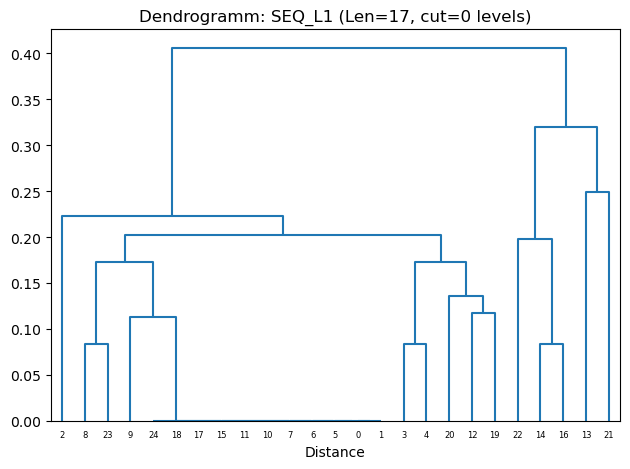


SEQ_L1, Länge 17 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 8x
      spike protein s1: 5x
      hemagglutinin: 3x
      surface glycoprotein: 2x
      gametocyte surface protein p230: 2x
      tumor necrosis factor receptor superfamily member 5: 2x
      spike protein s2': 1x
      programmed cell death protein 1: 1x
      receptor tyrosine-protein kinase erbb-2: 1x
    PDB_IDs:
      8ekd
      8d48
      7eng
      7mzk
      7kn3
      7k9z
      7czy
      7d0d
      7ps2
      7czx
      7uvs
      7ubs
      8dnn
      8ume
      8suo
      8gf2
      8cwj
      7prz
      7fjo
      6xq4
      6xkr
      6pe9
      6pe8
      6att
      6xpx
    Sequenzen:
      KSSQSVLYAANNKNYLA
      KSSRNVLYSSNNKNYLA
      KSSQSVLYRSNNKNYLA
      KSSQSVLYSSNNKNYLG
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
      KSSQSVLYSSNNKNYLA
   

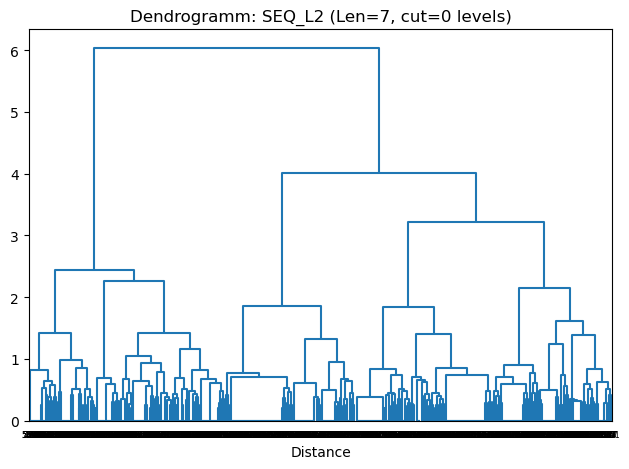


SEQ_L2, Länge 7 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 211x
      spike protein s1: 179x
      hemagglutinin: 47x
      neuraminidase: 25x
      surface glycoprotein: 25x
      fusion glycoprotein f0: 17x
      gametocyte surface protein p230: 15x
      circumsporozoite protein: 12x
      envelope glycoprotein e2: 12x
      clade a/e 93th057 hiv-1 gp120 core: 11x
      programmed cell death protein 1: 11x
      spike glycoprotein,fibritin: 9x
      envelope glycoprotein gp160: 9x
      receptor tyrosine-protein kinase erbb-2: 8x
      envelope glycoprotein b: 8x
      envelope glycoprotein gp120: 8x
      reticulocyte binding protein 2b: 7x
      interleukin-17a: 7x
      ch848.10.17 gp120: 7x
      leukocyte surface antigen cd47: 7x
      25 kda ookinete surface antigen: 6x
      envelope protein: 6x
      nucleoprotein: 6x
      reticulocyte-binding protein homolog 5: 6x
      epidermal growth factor receptor: 6x
      cytotoxic t-lymphocyte p

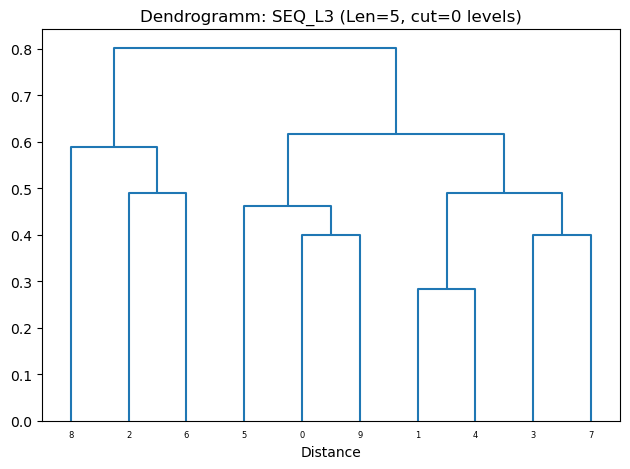


SEQ_L3, Länge 5 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      clade a/e 93th057 hiv-1 gp120 core: 2x
      envelope glycoprotein gp160: 2x
      spike glycoprotein: 2x
      envelope glycoprotein gp120: 1x
      glycoprotein 120: 1x
      spike protein s1: 1x
      hemagglutinin: 1x
    PDB_IDs:
      4jb9
      7ugq
      4ydi
      7rdw
      9cci
      4j6r
      8qh0
      6e4x
      7s6j
      5te6
    Sequenzen:
      QQFEF
      SAFEY
      QVIES
      QHMYT
      QQYDA
      QQYET
      QQGVT
      QQQGT
      QQPLT
      QVLQF

--------------------------------------------------

0
✅ TSV geschrieben: cdr_cluster_pre_decided_HC_length_tsvs/clusters_SEQ_L3_len8.tsv


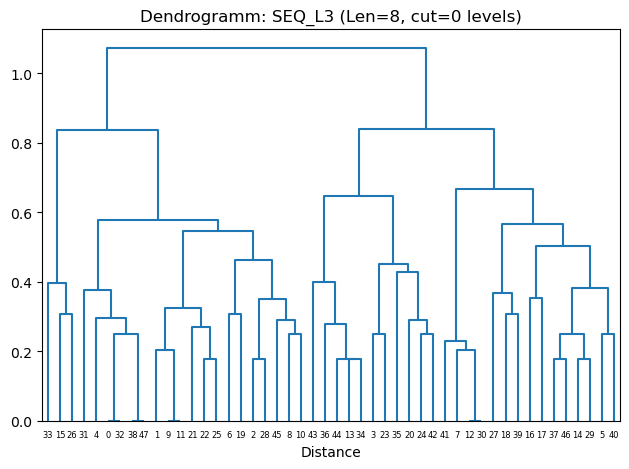


SEQ_L3, Länge 8 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 14x
      spike glycoprotein: 10x
      envelope glycoprotein gp160: 3x
      hemagglutinin: 3x
      clade a/e 93th057 hiv-1 gp120 core: 3x
      envelope glycoprotein e2: 2x
      spike protein: 2x
      circumsporozoite protein: 2x
      fusion glycoprotein f0: 1x
      hemagglutinin ha1: 1x
      surface glycoprotein: 1x
      envelope glycoprotein e: 1x
      spike protein s2': 1x
      reticulocyte-binding protein homolog 5: 1x
      tumor necrosis factor receptor superfamily member 5: 1x
      25 kda ookinete surface antigen: 1x
      programmed cell death 1 ligand 1: 1x
    PDB_IDs:
      5t3z
      8eay
      5w08
      7ljr
      8tzy
      9l6c
      6uyg
      7ps1
      7n62
      8v5q
      8suo
      8ekd
      8bbo
      7ul1
      7jmo
      8pwv
      7y6l
      8wyj
      7nx7
      5w42
      8x0y
      8yx1
      6oej
      6phc
      6c6z
      8bg1
      6iuv
      8wyj


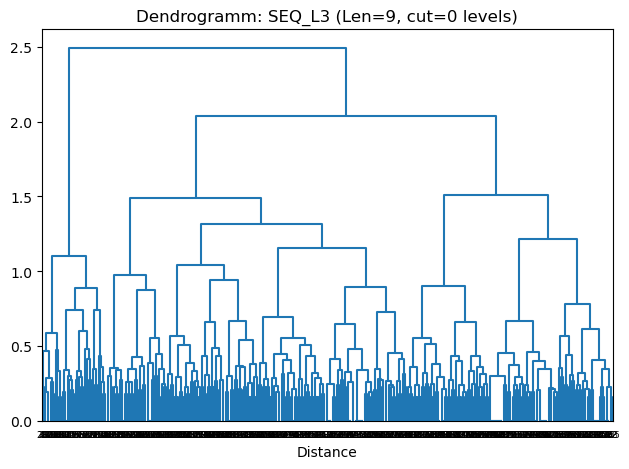


SEQ_L3, Länge 9 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 122x
      spike protein s1: 85x
      hemagglutinin: 33x
      programmed cell death protein 1: 11x
      surface glycoprotein: 11x
      envelope glycoprotein e2: 10x
      fusion glycoprotein f0: 10x
      neuraminidase: 8x
      gametocyte surface protein p230: 7x
      circumsporozoite protein: 6x
      cytotoxic t-lymphocyte protein 4: 6x
      leukocyte surface antigen cd47: 6x
      receptor tyrosine-protein kinase erbb-2: 6x
      interleukin-17a: 6x
      envelope glycoprotein b: 5x
      spike glycoprotein,fibritin: 5x
      epidermal growth factor receptor: 5x
      spike protein s2': 5x
      genome polyprotein: 4x
      e2 glycoprotein: 4x
      nucleoprotein: 4x
      envelope glycoprotein h: 4x
      vascular endothelial growth factor a: 4x
      histone chaperone asf1: 4x
      reticulocyte-binding protein homolog 5: 4x
      tumor necrosis factor receptor superfamily member

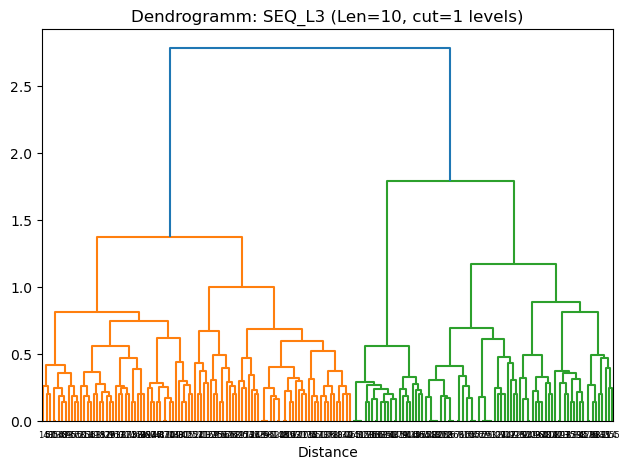


SEQ_L3, Länge 10 → 2 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike protein s1: 28x
      spike glycoprotein: 23x
      neuraminidase: 10x
      gametocyte surface protein p230: 6x
      surface glycoprotein: 6x
      hemagglutinin: 2x
      tyrosine-protein phosphatase non-receptor type substrate 1: 2x
      envelope protein e: 2x
      hemagglutinin ha1: 2x
      circumsporozoite protein: 2x
      envelope protein: 2x
      envelope glycoprotein b: 2x
      leukocyte surface antigen cd47: 1x
      cadmium and zinc efflux pump fief: 1x
      25 kda ookinete surface antigen: 1x
      reticulocyte-binding protein-like protein 5: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      envelope glycoprotein e: 1x
      erythropoietin receptor: 1x
      envelope glycoprotein gp120: 1x
      tumor necrosis factor receptor superfamily member 9: 1x
      t-cell immunoreceptor with ig and itim domains: 1x
      spike glycoprotein,fibritin: 1x
    PDB_IDs:
      8rp8
      8zr4
   

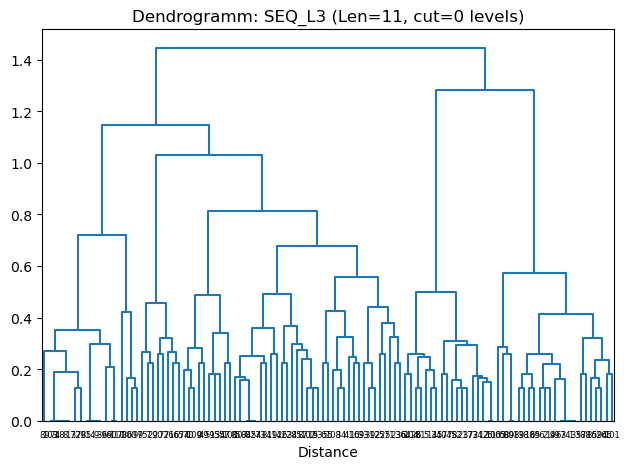


SEQ_L3, Länge 11 → 1 Subgruppen:
  Cluster 1:
    Antigen-Verteilung:
      spike glycoprotein: 39x
      spike protein s1: 25x
      hemagglutinin: 5x
      surface glycoprotein: 4x
      fusion glycoprotein f0: 4x
      envelope glycoprotein gp120: 3x
      neuraminidase: 3x
      reticulocyte binding protein 2b: 3x
      hemagglutinin ha1 chain: 3x
      erythropoietin receptor: 2x
      envelope protein: 2x
      glutamate receptor ionotropic, nmda 1: 1x
      spike protein: 1x
      ig epsilon chain c region: 1x
      tumor necrosis factor ligand superfamily member 13b: 1x
      receptor tyrosine-protein kinase erbb-2: 1x
      programmed cell death 1 ligand 1: 1x
      clade a/e 93th057 hiv-1 gp120 core: 1x
      envelope glycoprotein gp160: 1x
      envelope glycoprotein b: 1x
      tumor necrosis factor receptor superfamily member 9: 1x
      interleukin-17a: 1x
      nucleoprotein: 1x
      gametocyte surface protein p230: 1x
      25 kda ookinete surface antigen: 1x
      re

In [ ]:
import csv
import os
# Ausgabe-Ordner erstellen
os.makedirs("cdr_cluster_pre_decided_HC_length_tsvs", exist_ok=True)
# Anzahl Cluster pro (Region, Länge) aus SubDab
cluster_counts = {
    ("SEQ_H1", 7): 4, ("SEQ_H1", 8): 2, ("SEQ_H1", 9): 1,
    ("SEQ_H2", 5): 1, ("SEQ_H2", 6): 5, ("SEQ_H2", 8): 1,
    ("SEQ_L1",10): 1, ("SEQ_L1",11): 2, ("SEQ_L1",12): 2,
    ("SEQ_L1",13): 3, ("SEQ_L1",14): 3, ("SEQ_L1",15): 1,
    ("SEQ_L1",16): 1, ("SEQ_L1",17): 1,
    ("SEQ_L2", 7): 1,
    ("SEQ_L3", 5): 1, ("SEQ_L3", 8): 1, ("SEQ_L3", 9): 1,
    ("SEQ_L3",10): 2, ("SEQ_L3",11): 1,
}
for region in regions:
    lengths = sorted(df[region].str.len().dropna().unique())
    for L in lengths:
# Parameter für Dendrogramm-Cut
        levels_down = cluster_counts.get((region, L), 1)-1  # Anzahl der Ebenen für den Cut; etwa 2 = 3 Teilbäume
        print(levels_down)
# Liste der 20 Standard-Aminosäuren
        AA_LIST = list("ACDEFGHIKLMNPQRSTVWY")

        def aa_freq_vector(seq: str) -> np.ndarray:
            """Berechnet den normierten Häufigkeitsvektor der 20 Standard-Aminosäuren."""
            counts = np.array([seq.count(aa) for aa in AA_LIST], dtype=float)
            return counts / len(seq)


        sub_df = df[df[region].str.len() == L].reset_index(drop=True)
        seqs = sub_df[region].tolist()
        X = np.vstack([aa_freq_vector(s) for s in seqs])

        # Hierarchisches Clustering
        Z = linkage(X, method="ward", metric="euclidean")
        threshold = Z[-levels_down, 2] if levels_down <= Z.shape[0] else 0.0

        # Dendrogrammdaten ohne Plot für Farbzuordnung
        ddata = dendrogram(
            Z,
            labels=[str(i) for i in range(len(seqs))],
            color_threshold=threshold,
            no_plot=True
        )

        # Blatt-Farben extrahieren
        leaves = ddata['leaves']
        leaf_colors = ddata['leaves_color_list']
        leaf_color_map = dict(zip(leaves, leaf_colors))

        # Eindeutige Farben in Erscheinungsreihenfolge sammeln
        unique_colors = []
        for col in leaf_colors:
            if col not in unique_colors:
                unique_colors.append(col)
        color_cluster_map = {col: idx+1 for idx, col in enumerate(unique_colors)}

        # TSV-Einträge sammeln
        entries = []
        for col in unique_colors:
            cid = color_cluster_map[col]
            leaves_in_cluster = [leaf for leaf, c in leaf_color_map.items() if c == col]
            for leaf_idx in leaves_in_cluster:
                pdb_id = sub_df.iloc[leaf_idx]['PDB_ID']
                entries.append((pdb_id, region, L, cid))

        # Schreibe TSV für Region und Länge
        tsv_file = f"cdr_cluster_pre_decided_HC_length_tsvs/clusters_{region}_len{L}.tsv"
        with open(tsv_file, 'w', newline='') as f:
            writer = csv.writer(f, delimiter='\t')
            writer.writerow(["PDB_ID", "CDR", "Length", "Cluster_Label"])
            writer.writerows(entries)
        print(f"✅ TSV geschrieben: {tsv_file}")

        # Plot Dendrogramm        plt.figure(figsize=(8, 6))
        dendrogram(
            Z,
            labels=[str(i) for i in range(len(seqs))],
            color_threshold=threshold,
            leaf_rotation=0,
            leaf_font_size=6
        )
        plt.title(f"Dendrogramm: {region} (Len={L}, cut={levels_down} levels)")
        plt.xlabel("Distance")
        plt.tight_layout()
        plt.show()

        # Konsolenausgabe der Cluster-Inhalte
        print(f"\n{region}, Länge {L} → {len(unique_colors)} Subgruppen:")
        for col in unique_colors:
            cid = color_cluster_map[col]
            leaves_in_cluster = [leaf for leaf, c in leaf_color_map.items() if c == col]
            antigens = sub_df.loc[leaves_in_cluster, 'antigen_name']
            pdbs = sub_df.loc[leaves_in_cluster, 'PDB_ID']
            seq_list = sub_df.loc[leaves_in_cluster, region]

            counts = Counter(antigens)
            print(f"  Cluster {cid}:")
            print("    Antigen-Verteilung:")
            for ag, cnt in counts.most_common():
                print(f"      {ag}: {cnt}x")
            print("    PDB_IDs:")
            for p in pdbs:
                print(f"      {p}")
            print("    Sequenzen:")
            for s in seq_list:
                print(f"      {s}")
        print("\n" + "-"*50 + "\n")